# Multivariate analysis

In [1]:
%load_ext autoreload
%autoreload 2

import os
import pandas as pd
import matplotlib.pyplot as plt

reliability_df = pd.read_csv("../../data/cross_split_metrics.csv")
quality_df     = pd.read_csv("../../data/image_quality_metrics.csv")
infodump_df    = pd.read_csv("../../data/raw_subject_data.csv")
subjects_df    = pd.read_csv("../../data/subject.csv")
split_comp_df  = pd.read_csv("../../data/split_comparision_data.csv")

import _functions as mf
from _functions import (
    run_regression_model,
    plot_coefficients,
    plot_r2_comparison,
    plot_diagnostic_suite,
    plot_ols_table,
    compare_models,
    residualize,
)

ASSETS = "../../assets/artifacts"
os.makedirs(ASSETS, exist_ok=True)

PRED_LABELS = {
    "GA": "GA (weeks)",
    "snr_diff_sp": "SNR Diff (SP)",
    "snr_diff_cp": "SNR Diff (CP)",
    "qa_diff": "QA Diff",
    "qa_mean": "QA Mean",
    "stack_count": "Stack Count",
    "stack_count_resid": "Stack Count (resid.)",
    "cnr_diff": "CNR Diff",
    "cnr_mean": "CNR Mean",
}


## Vol_diff ~ GA + SNR_diff + QA_diff + stack_count


Table: Regression of SP Volume Diff (S1-S2)
Variable       Coef     SE       t    p-value
-----------  ------  -----  ------  ---------
Intercept    -1.618  1.142  -1.420      0.174
GA            0.076  0.038   1.990      0.063
qa_diff      -1.411  1.326  -1.060      0.302
stack_count  -0.007  0.035  -0.190      0.852
snr_diff_sp   0.449  0.270   1.660      0.114
R-squared            0.284
Adj. R-squared       0.124
N                       23
F-statistic           1.78

Collinearity Statistics (VIF):
  Variable             VIF
  -------------------------
  GA                  8.20 *
  qa_diff             2.72
  stack_count         6.38 *
  snr_diff_sp         2.71

Table: Regression of SP Volume Diff (S3-S4)
Variable       Coef     SE       t  p-value
-----------  ------  -----  ------  ---------
Intercept    -2.955  1.425  -2.070  0.053
GA            0.110  0.046   2.400  0.027 *
qa_diff       2.953  1.527   1.930  0.069
stack_count   0.023  0.037   0.610  0.551
snr_diff_sp   0.103  

Saved: ../../assets/mv_01_snr_coef.png


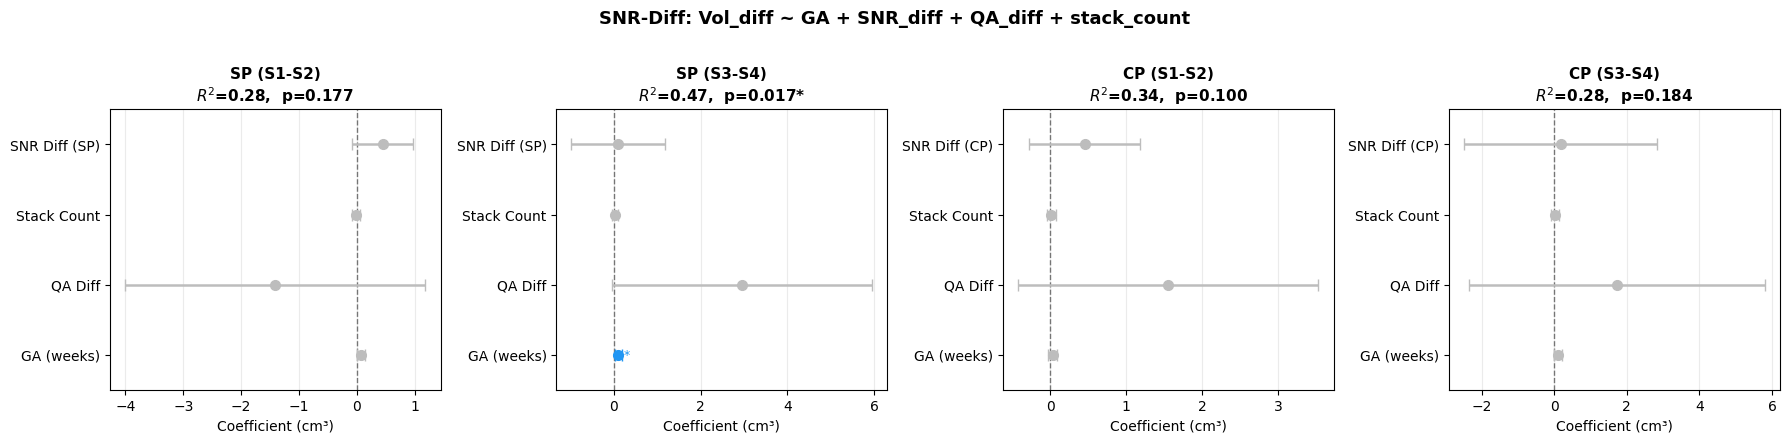

Saved: ../../assets/mv_01_snr_sp_S1S2_partial.png
  Shapiro-Wilk [SP (S1-S2)]: W=0.9705, p=0.7008 (normal)


Saved: ../../assets/mv_01_snr_sp_S1S2_resid.png


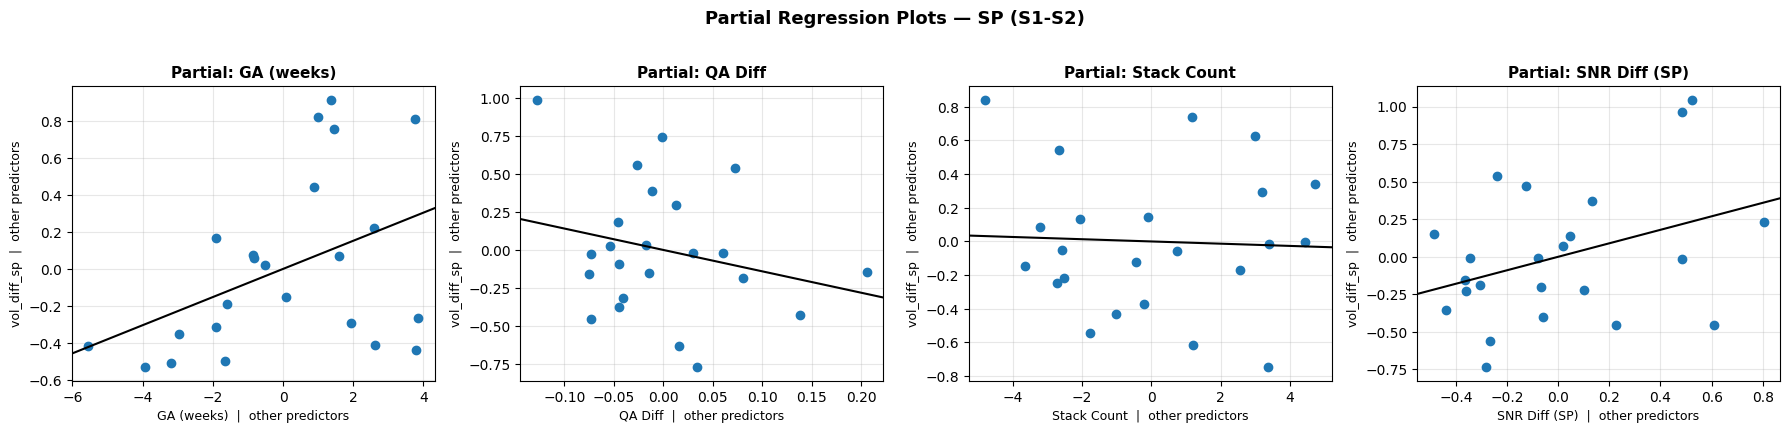

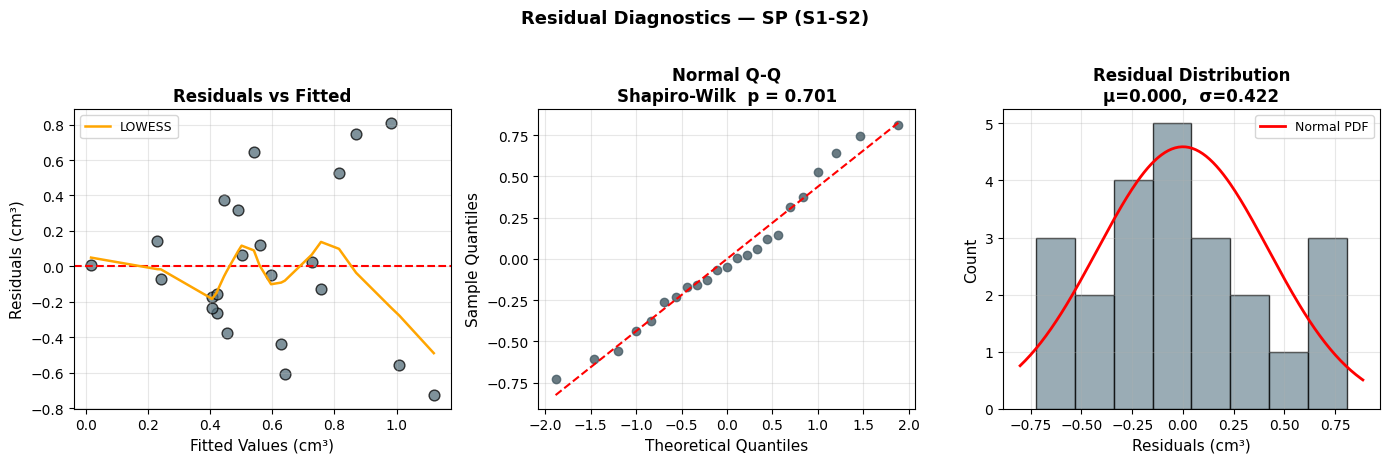

Saved: ../../assets/mv_01_snr_sp_S3S4_partial.png
  Shapiro-Wilk [SP (S3-S4)]: W=0.9702, p=0.6945 (normal)


Saved: ../../assets/mv_01_snr_sp_S3S4_resid.png


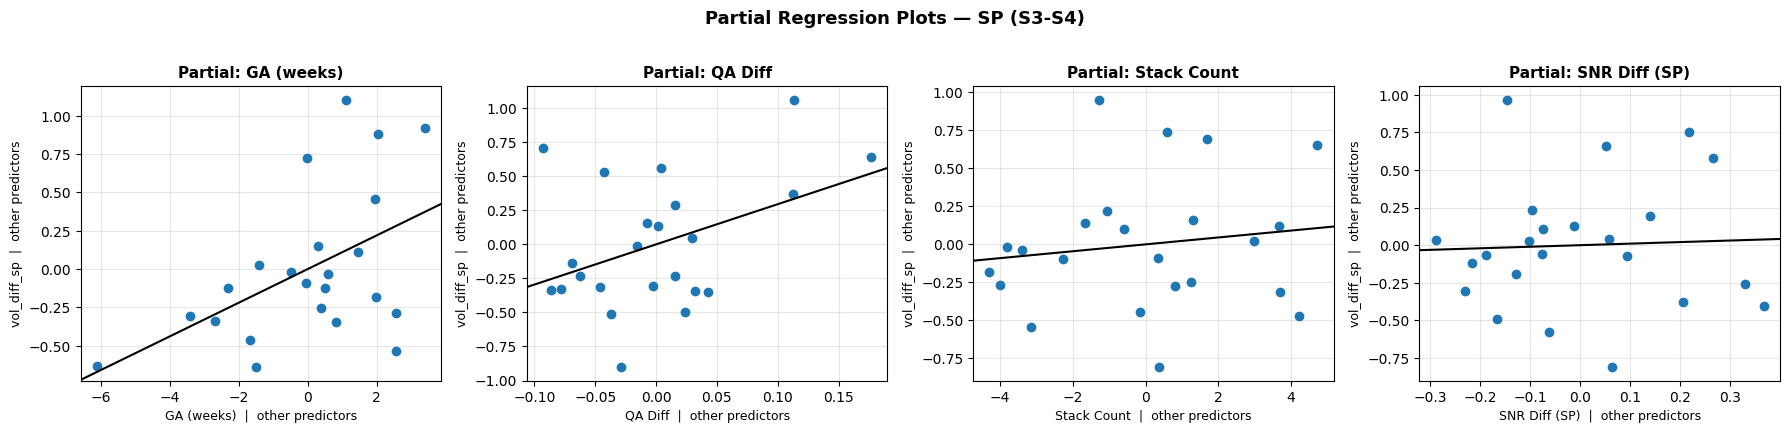

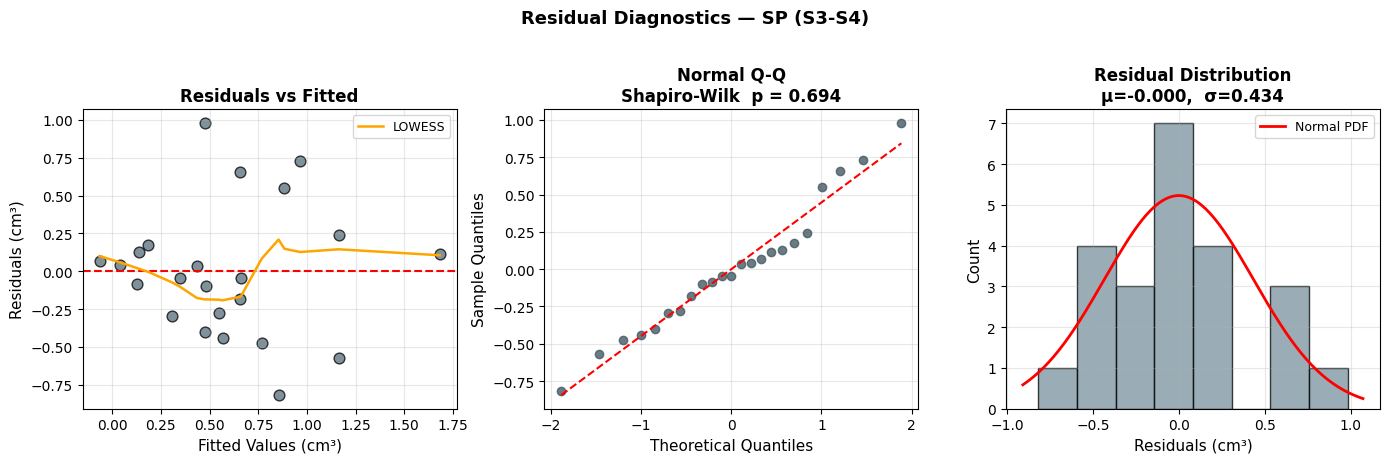

Saved: ../../assets/mv_01_snr_cp_S1S2_partial.png
  Shapiro-Wilk [CP (S1-S2)]: W=0.9658, p=0.5887 (normal)


Saved: ../../assets/mv_01_snr_cp_S1S2_resid.png


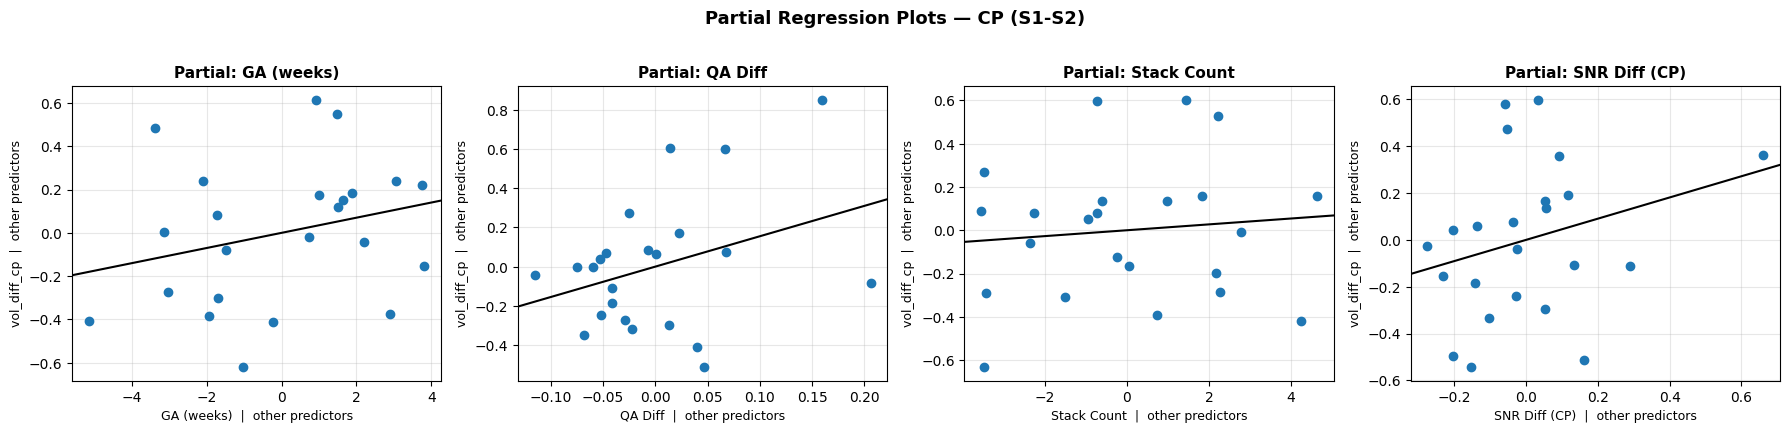

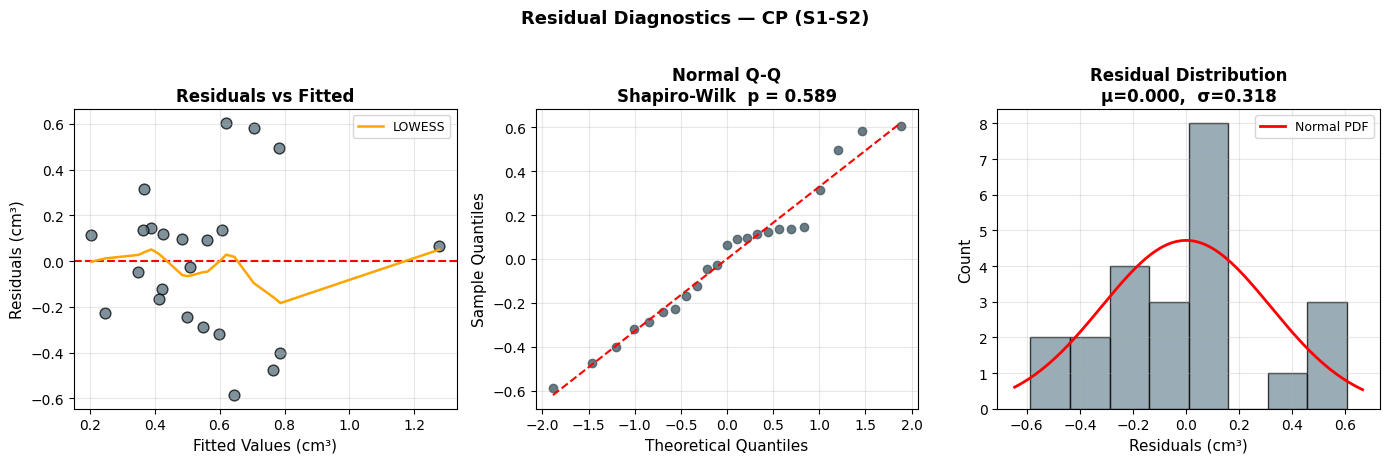

Saved: ../../assets/mv_01_snr_cp_S3S4_partial.png
  Shapiro-Wilk [CP (S3-S4)]: W=0.8644, p=0.0050 (non-normal)


Saved: ../../assets/mv_01_snr_cp_S3S4_resid.png


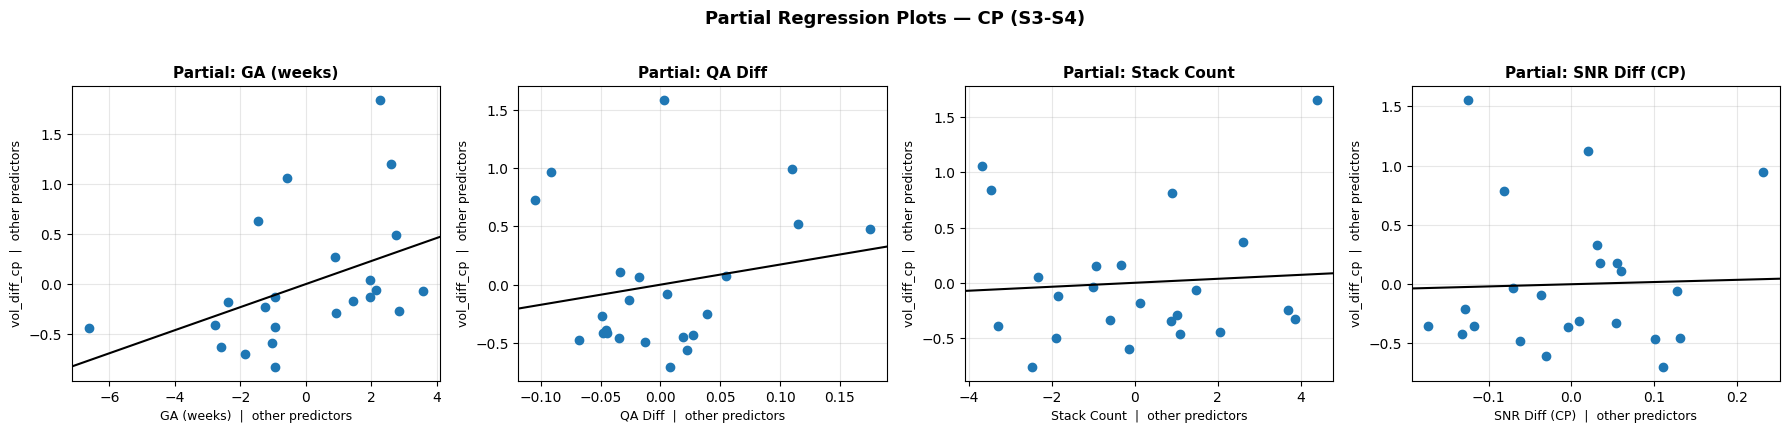

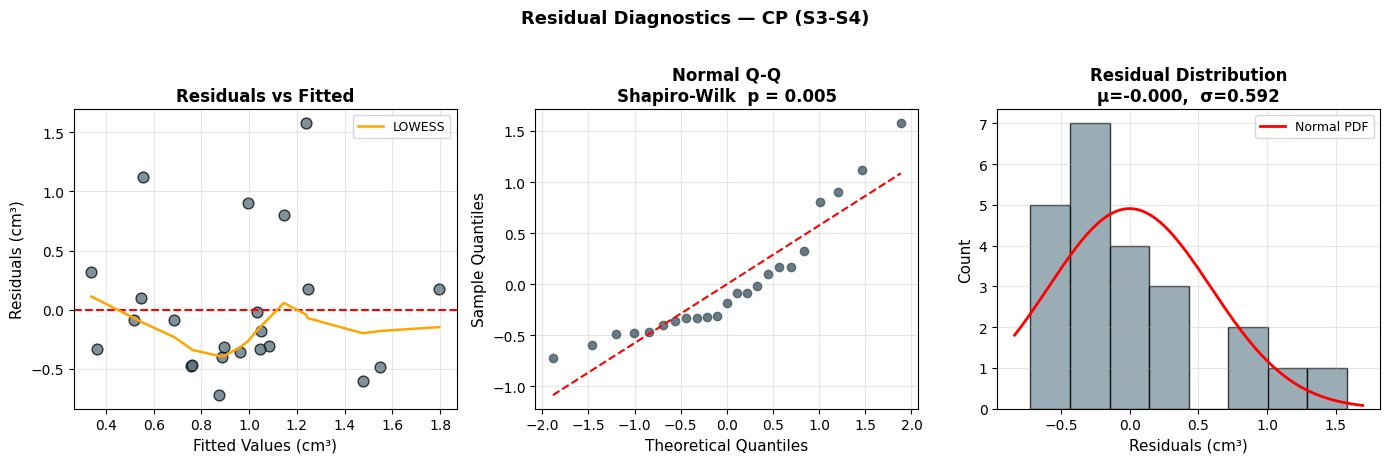

Saved: ../../assets/mv_01_snr_table.png


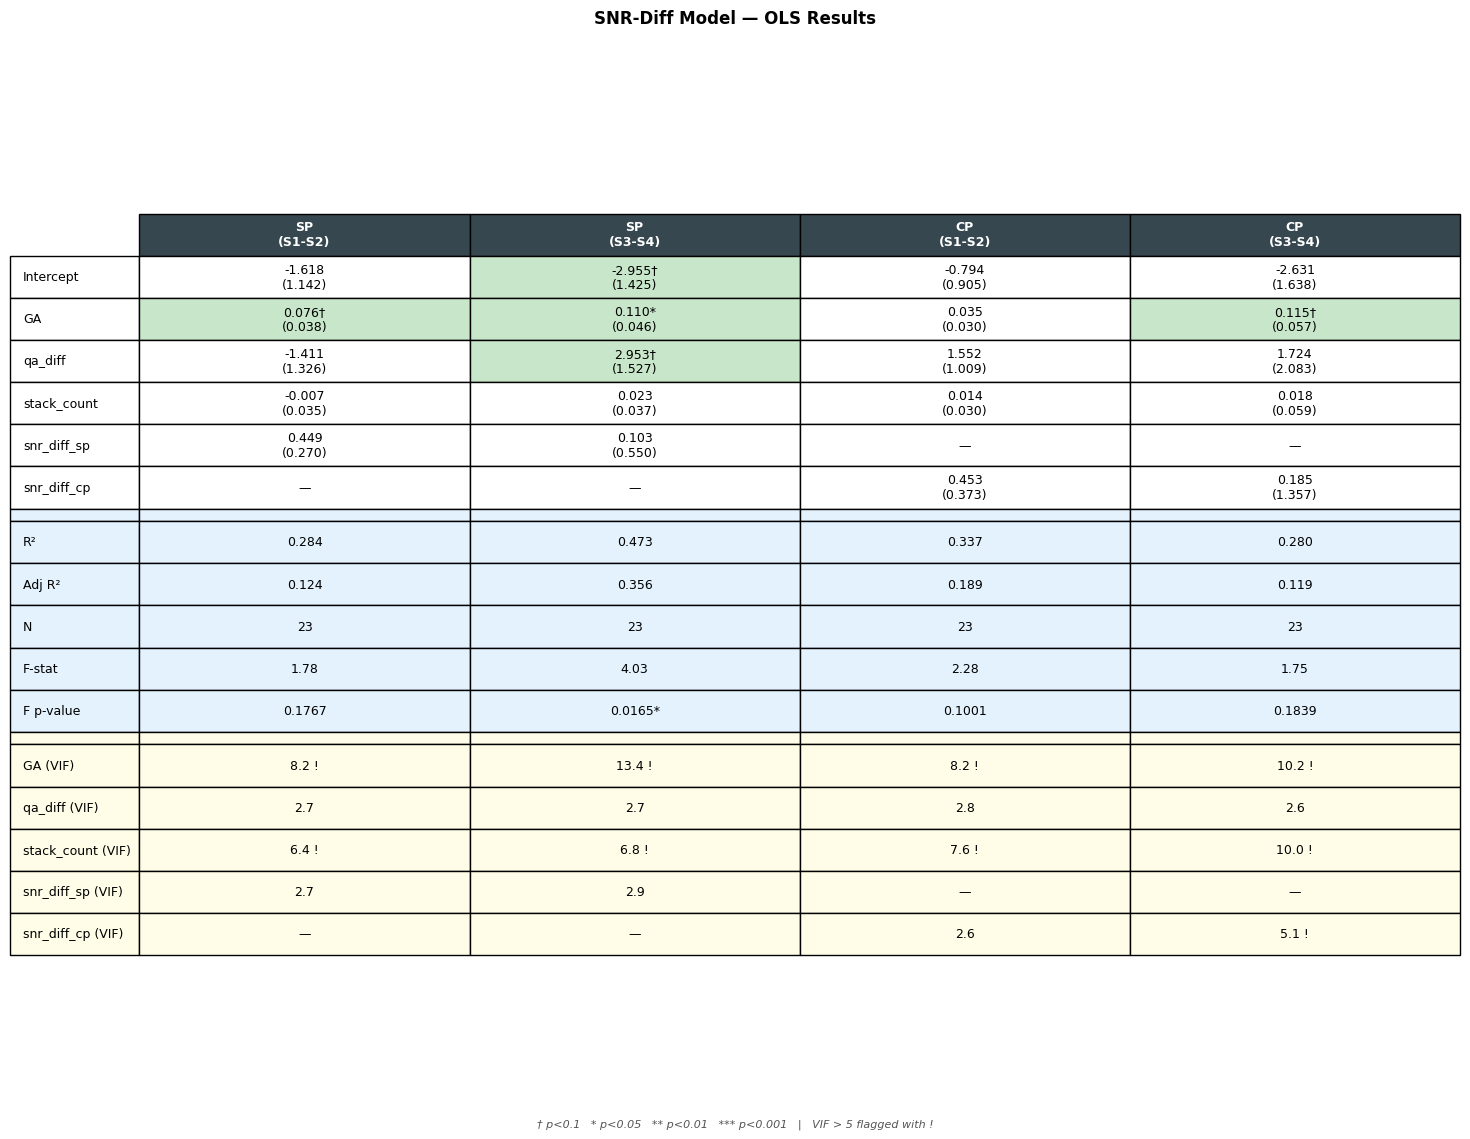

In [2]:
data_S1S2 = mf.prepare_analysis_data(quality_df, infodump_df, split_comp_df, "S1-S2")
data_S3S4 = mf.prepare_analysis_data(quality_df, infodump_df, split_comp_df, "S3-S4")
predictors_base = ["GA", "qa_diff", "stack_count"]
model_configs = [
    (data_S1S2, "vol_diff_sp", "snr_diff_sp", "sp", "S1-S2", "Subplate"),
    (data_S3S4, "vol_diff_sp", "snr_diff_sp", "sp", "S3-S4", "Subplate"),
    (data_S1S2, "vol_diff_cp", "snr_diff_cp", "cp", "S1-S2", "Cortical Plate"),
    (data_S3S4, "vol_diff_cp", "snr_diff_cp", "cp", "S3-S4", "Cortical Plate"),
]
results_snr = []
for data, outcome_col, snr_col, tissue, split_pair, tissue_name in model_configs:
    result = run_regression_model(
        df=data, outcome_col=outcome_col,
        predictors=predictors_base + [snr_col],
        model_name="SNR-Diff", split_pair=split_pair, tissue=tissue,
    )
    results_snr.append(result)

compare_models(results_snr)

fig = plot_coefficients(results_snr, title="SNR-Diff: Vol_diff ~ GA + SNR_diff + QA_diff + stack_count",
    predictor_labels=PRED_LABELS, save_path=f"{ASSETS}/mv_01_snr_coef.png")
plt.show()

for i, (data, outcome_col, snr_col, tissue, split_pair, tissue_name) in enumerate(model_configs):
    r = results_snr[i]
    if r is None: continue
    slug = f"{tissue}_{split_pair.replace('-','')}"
    fig1, fig2 = plot_diagnostic_suite(data, outcome_col, r,
        tissue_name=tissue.upper(), split_pair=split_pair,
        predictor_labels=PRED_LABELS,
        save_path_prefix=f"{ASSETS}/mv_01_snr_{slug}")
    plt.show(); plt.show()

fig = plot_ols_table(results_snr, title="SNR-Diff Model — OLS Results",
    save_path=f"{ASSETS}/mv_01_snr_table.png")
plt.show()


Residualizing: stack_count ~ GA
  Original correlation: r = -0.159, p = 0.4696
  Regression R² = 0.0252
  Slope = -0.1793 (p = 0.4696)
  Residuals capture 97.5% unique variance
Residualizing: stack_count ~ GA
  Original correlation: r = -0.159, p = 0.4696
  Regression R² = 0.0252
  Slope = -0.1793 (p = 0.4696)
  Residuals capture 97.5% unique variance

Table: Regression of SP Volume Diff (S1-S2)
Variable             Coef     SE       t    p-value
-----------------  ------  -----  ------  ---------
Intercept          -1.697  1.078  -1.570      0.133
GA                  0.077  0.038   2.040      0.057
qa_diff            -1.411  1.326  -1.060      0.302
stack_count_resid  -0.007  0.035  -0.190      0.852
snr_diff_sp         0.449  0.270   1.660      0.114
R-squared            0.284
Adj. R-squared       0.124
N                       23
F-statistic           1.78

Collinearity Statistics (VIF):
  Variable             VIF
  -------------------------
  GA                  3.62
  qa_diff      

Saved: ../../assets/mv_02_resid_coef.png


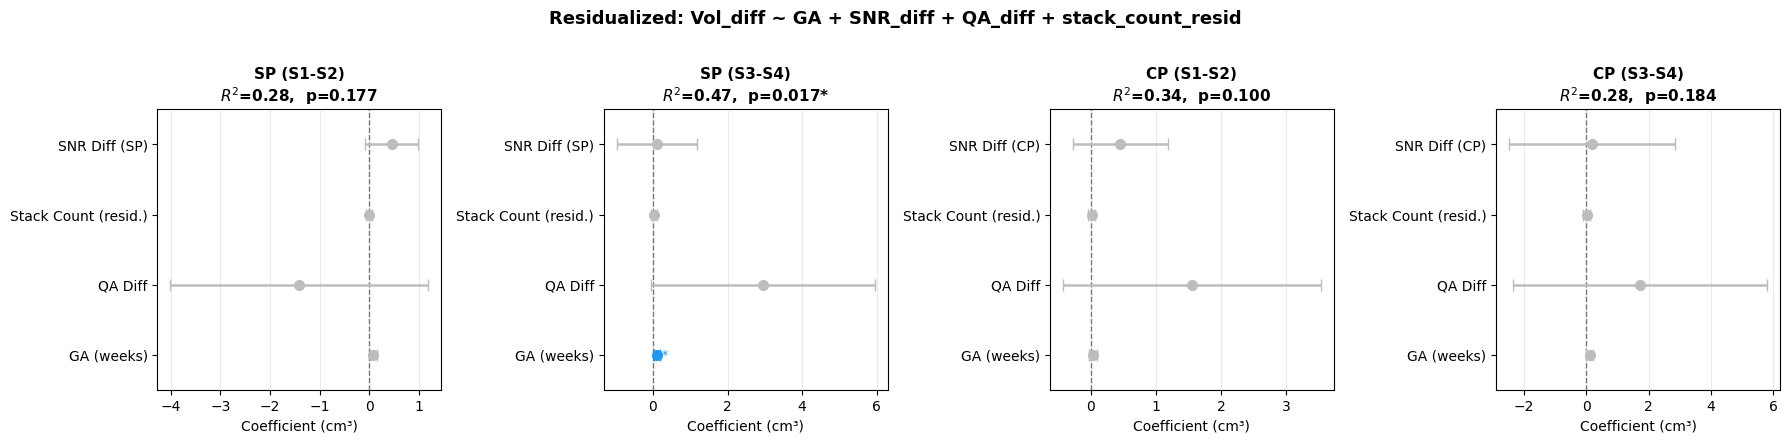

Saved: ../../assets/mv_02_resid_sp_S1S2_partial.png
  Shapiro-Wilk [SP (S1-S2)]: W=0.9705, p=0.7008 (normal)


Saved: ../../assets/mv_02_resid_sp_S1S2_resid.png


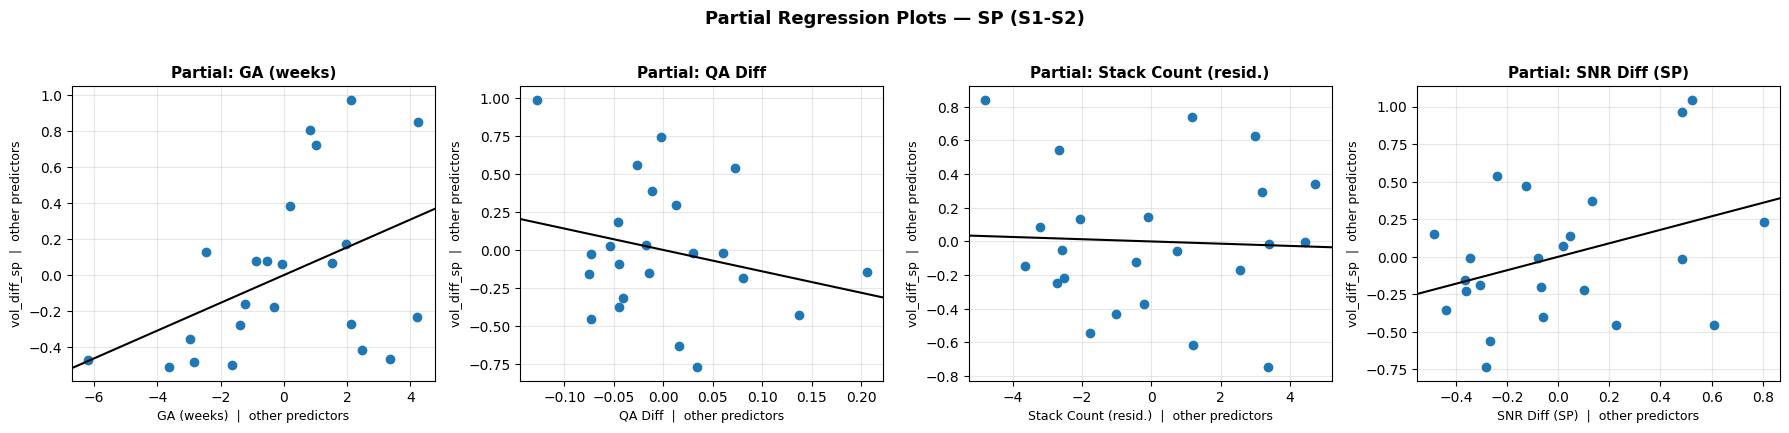

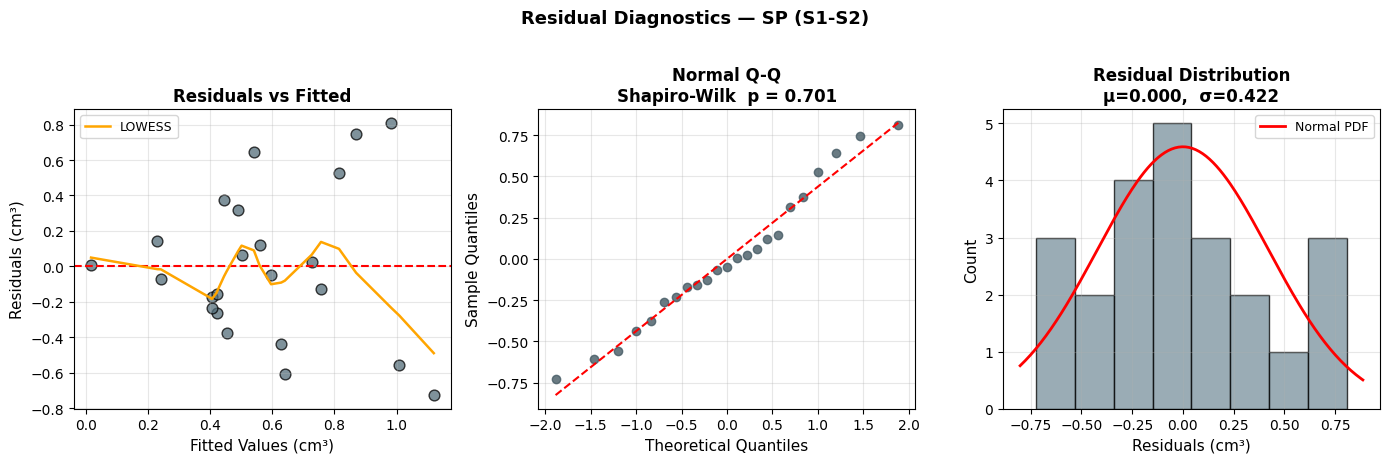

Saved: ../../assets/mv_02_resid_sp_S3S4_partial.png
  Shapiro-Wilk [SP (S3-S4)]: W=0.9702, p=0.6945 (normal)


Saved: ../../assets/mv_02_resid_sp_S3S4_resid.png


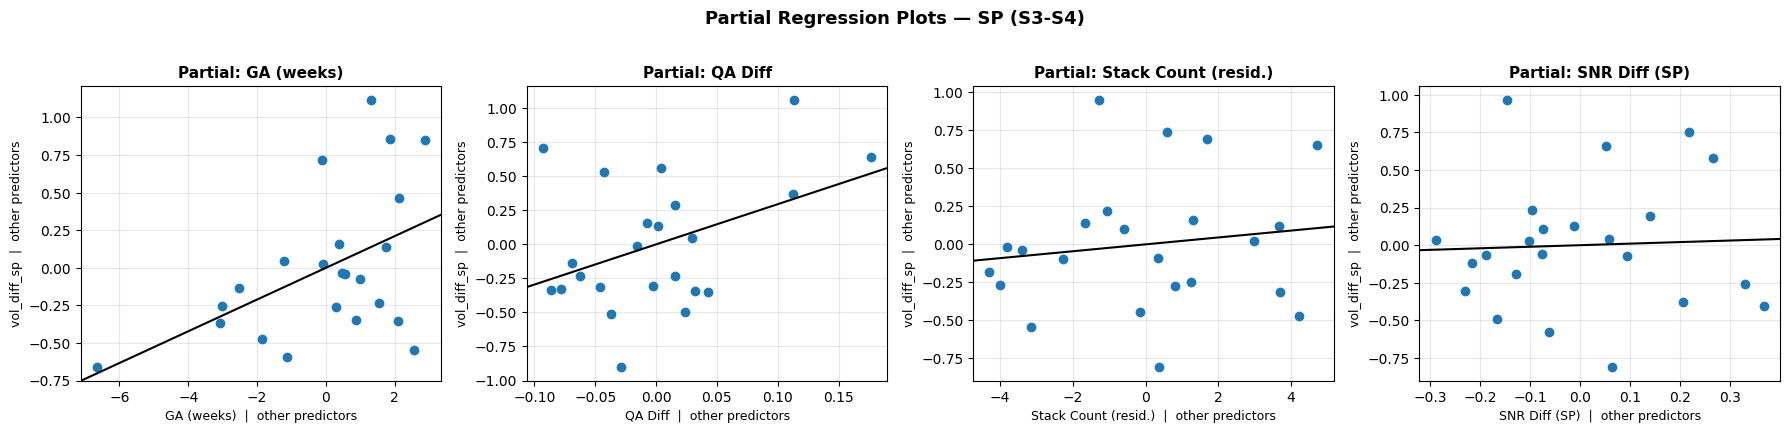

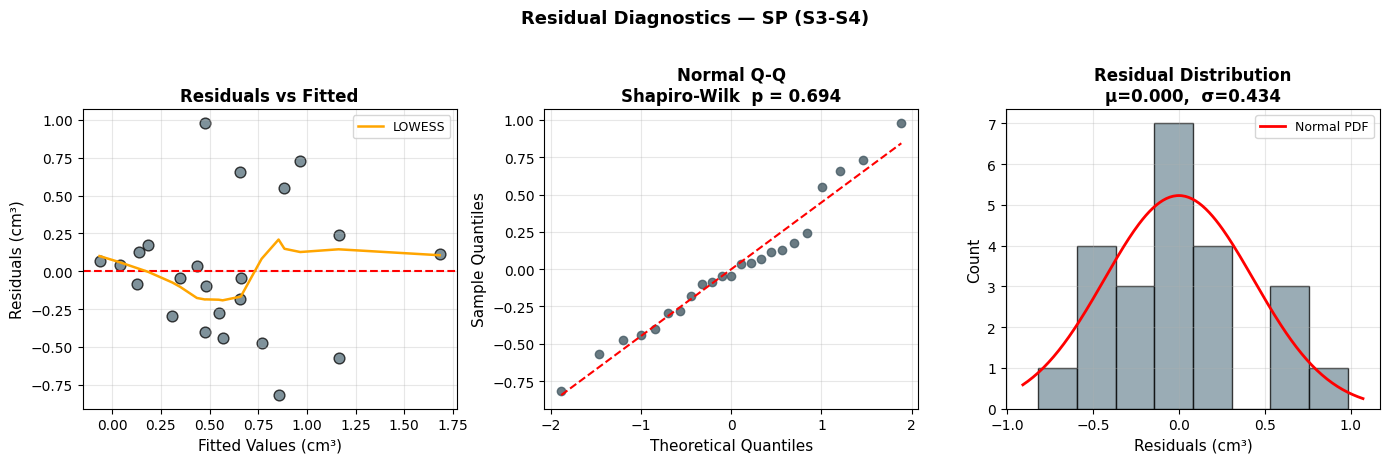

Saved: ../../assets/mv_02_resid_cp_S1S2_partial.png
  Shapiro-Wilk [CP (S1-S2)]: W=0.9658, p=0.5887 (normal)


Saved: ../../assets/mv_02_resid_cp_S1S2_resid.png


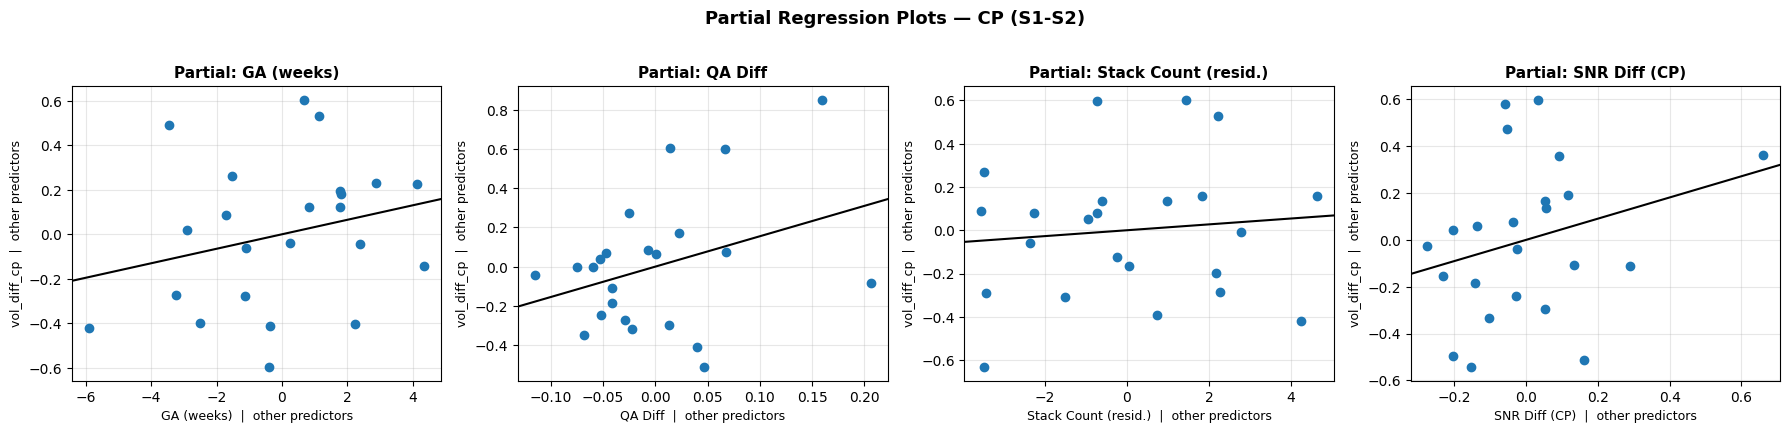

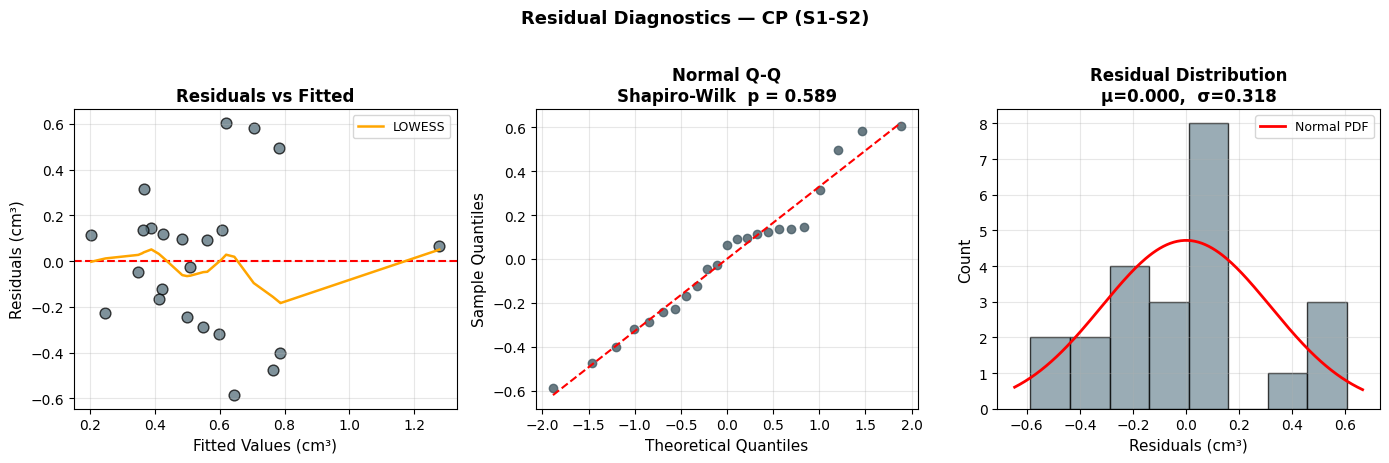

Saved: ../../assets/mv_02_resid_cp_S3S4_partial.png
  Shapiro-Wilk [CP (S3-S4)]: W=0.8644, p=0.0050 (non-normal)


Saved: ../../assets/mv_02_resid_cp_S3S4_resid.png


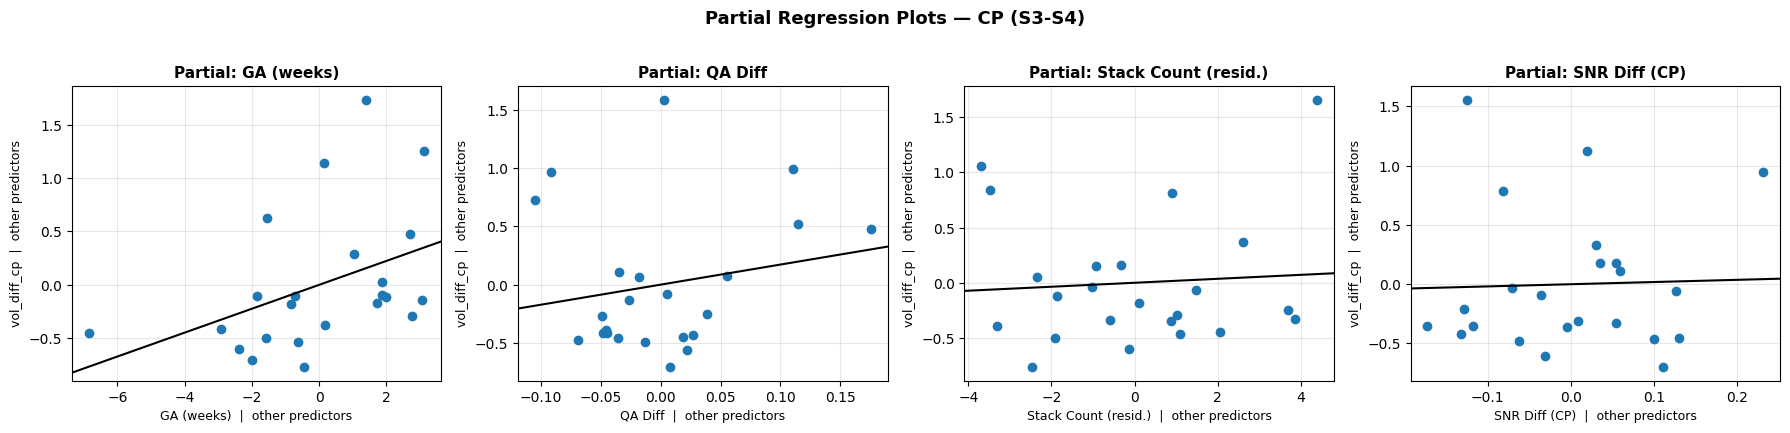

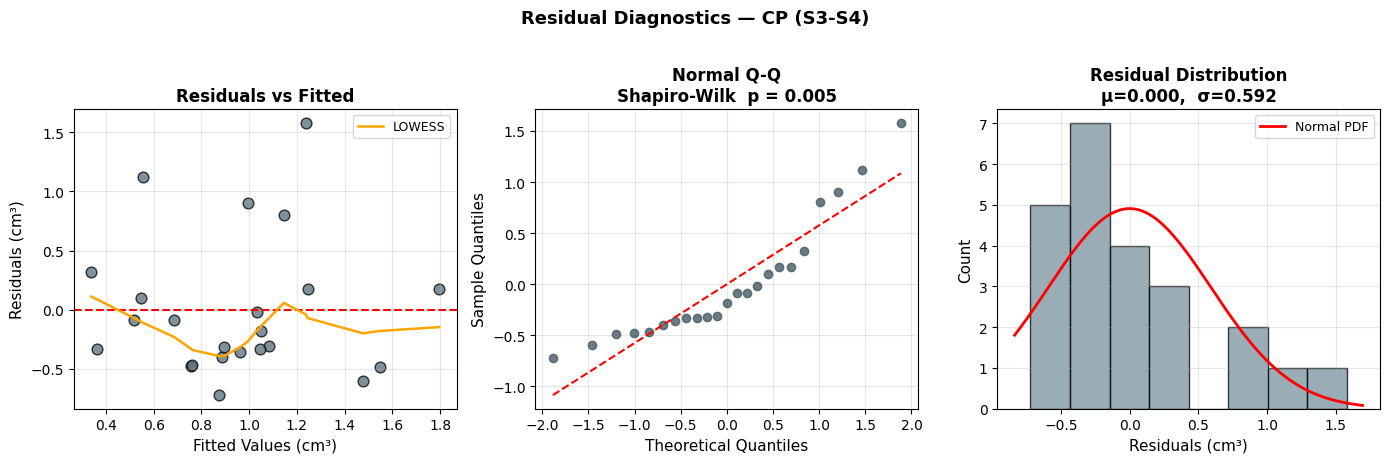

Saved: ../../assets/mv_02_resid_table.png


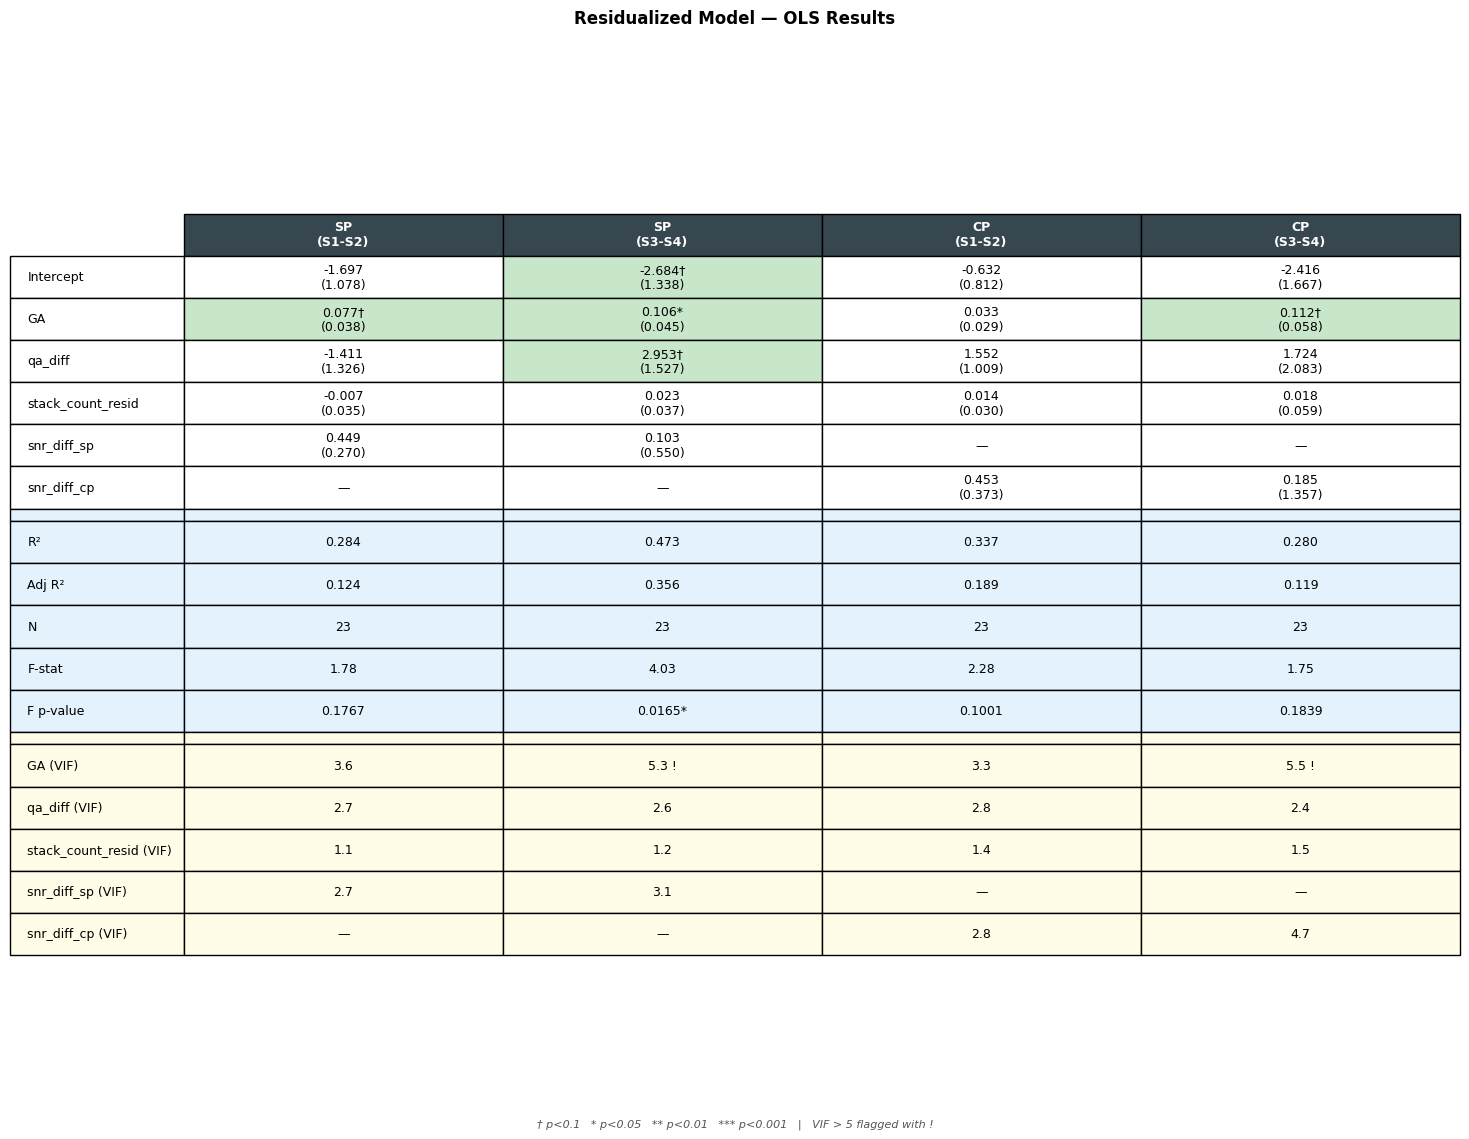

In [3]:
data_resid_S1S2 = mf.prepare_analysis_data(quality_df, infodump_df, split_comp_df, "S1-S2")
data_resid_S1S2["stack_count_resid"] = residualize(data_resid_S1S2, "stack_count", "GA")
data_resid_S3S4 = mf.prepare_analysis_data(quality_df, infodump_df, split_comp_df, "S3-S4")
data_resid_S3S4["stack_count_resid"] = residualize(data_resid_S3S4, "stack_count", "GA")

resid_predictors = ["GA", "qa_diff", "stack_count_resid"]
resid_configs = [
    (data_resid_S1S2, "vol_diff_sp", "snr_diff_sp", "sp", "S1-S2", "Subplate"),
    (data_resid_S3S4, "vol_diff_sp", "snr_diff_sp", "sp", "S3-S4", "Subplate"),
    (data_resid_S1S2, "vol_diff_cp", "snr_diff_cp", "cp", "S1-S2", "Cortical Plate"),
    (data_resid_S3S4, "vol_diff_cp", "snr_diff_cp", "cp", "S3-S4", "Cortical Plate"),
]

results_resid = []
for data, outcome_col, snr_col, tissue, split_pair, tissue_name in resid_configs:
    result = run_regression_model(df=data, outcome_col=outcome_col,
        predictors=resid_predictors + [snr_col],
        model_name="Residualized", split_pair=split_pair, tissue=tissue)
    results_resid.append(result)

compare_models(results_resid)

fig = plot_coefficients(results_resid, title="Residualized: Vol_diff ~ GA + SNR_diff + QA_diff + stack_count_resid",
    predictor_labels=PRED_LABELS, save_path=f"{ASSETS}/mv_02_resid_coef.png")
plt.show()

for i, (data, outcome_col, snr_col, tissue, split_pair, tissue_name) in enumerate(resid_configs):
    r = results_resid[i]
    if r is None: continue
    slug = f"{tissue}_{split_pair.replace('-','')}"
    fig1, fig2 = plot_diagnostic_suite(data, outcome_col, r,
        tissue_name=tissue.upper(), split_pair=split_pair,
        predictor_labels=PRED_LABELS,
        save_path_prefix=f"{ASSETS}/mv_02_resid_{slug}")
    plt.show(); plt.show()

fig = plot_ols_table(results_resid, title="Residualized Model — OLS Results",
    save_path=f"{ASSETS}/mv_02_resid_table.png")
plt.show()



Table: Regression of SP Volume Diff (S1-S2)
Variable       Coef     SE       t    p-value
-----------  ------  -----  ------  ---------
Intercept    -1.177  1.210  -0.970      0.343
GA            0.077  0.038   2.010      0.060
qa_mean      -0.736  0.694  -1.060      0.303
stack_count  -0.018  0.038  -0.480      0.640
snr_diff_sp   0.354  0.267   1.320      0.202
R-squared            0.283
Adj. R-squared       0.124
N                       23
F-statistic           1.78

Collinearity Statistics (VIF):
  Variable             VIF
  -------------------------
  GA                 35.70 *
  qa_mean            21.13 *
  stack_count         6.98 *
  snr_diff_sp         2.65

Table: Regression of SP Volume Diff (S3-S4)
Variable       Coef     SE       t  p-value
-----------  ------  -----  ------  ---------
Intercept    -3.784  1.576  -2.400  0.027 *
GA            0.123  0.047   2.600  0.018 *
qa_mean       1.062  0.907   1.170  0.257
stack_count   0.024  0.043   0.550  0.590
snr_diff_sp   0.0

Saved: ../../assets/mv_03_qamean_coef.png


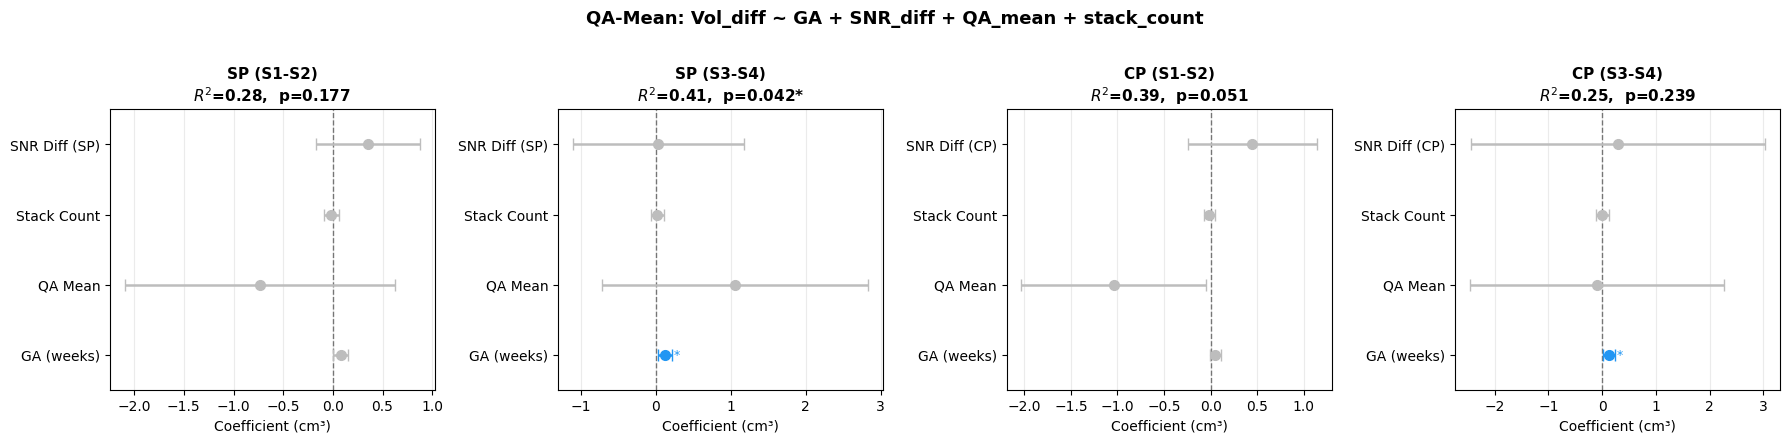

Saved: ../../assets/mv_03_qamean_sp_S1S2_partial.png
  Shapiro-Wilk [SP (S1-S2)]: W=0.9788, p=0.8855 (normal)


Saved: ../../assets/mv_03_qamean_sp_S1S2_resid.png


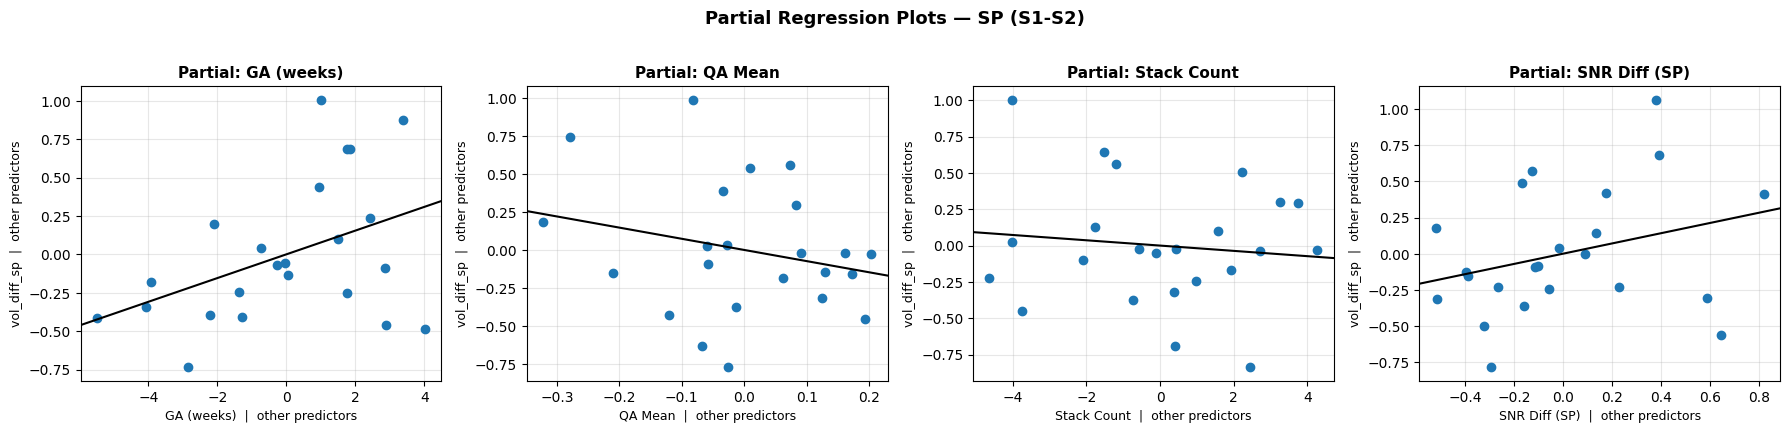

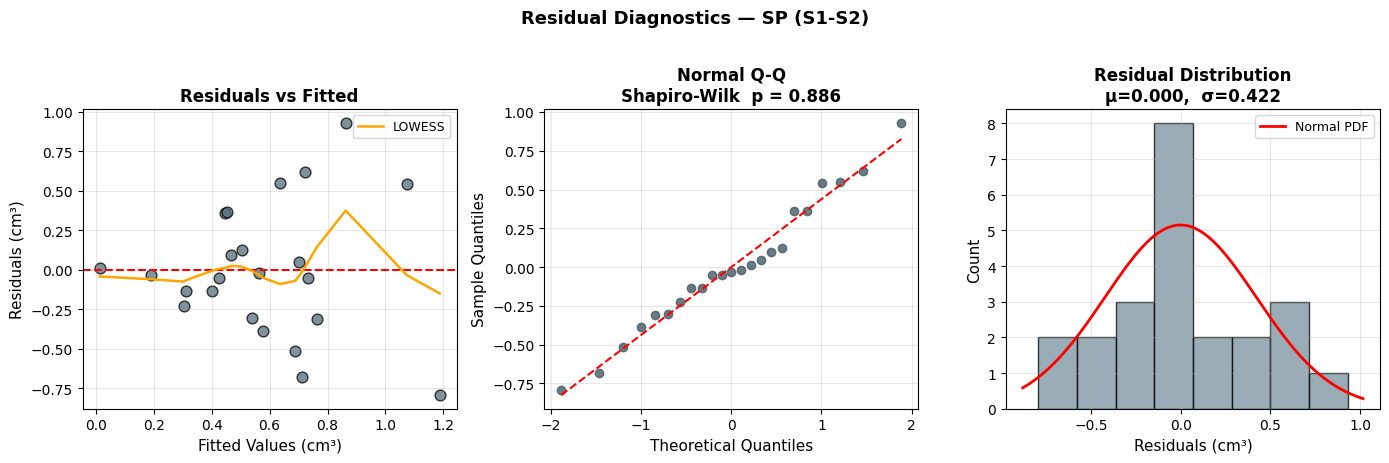

Saved: ../../assets/mv_03_qamean_sp_S3S4_partial.png
  Shapiro-Wilk [SP (S3-S4)]: W=0.9570, p=0.4059 (normal)


Saved: ../../assets/mv_03_qamean_sp_S3S4_resid.png


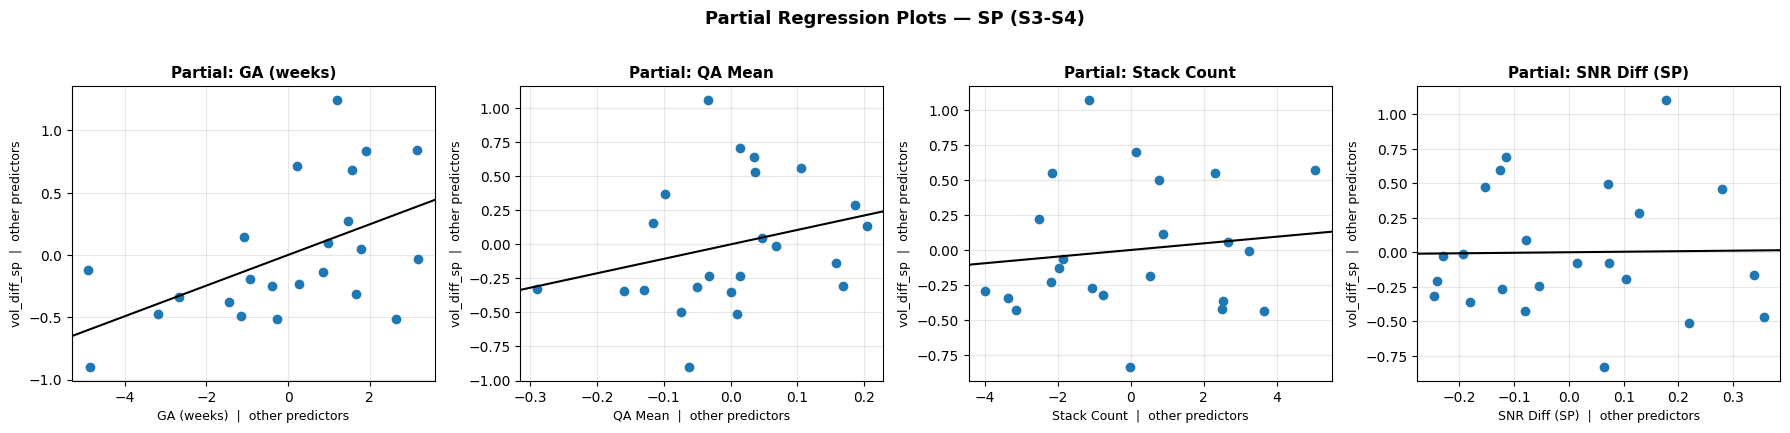

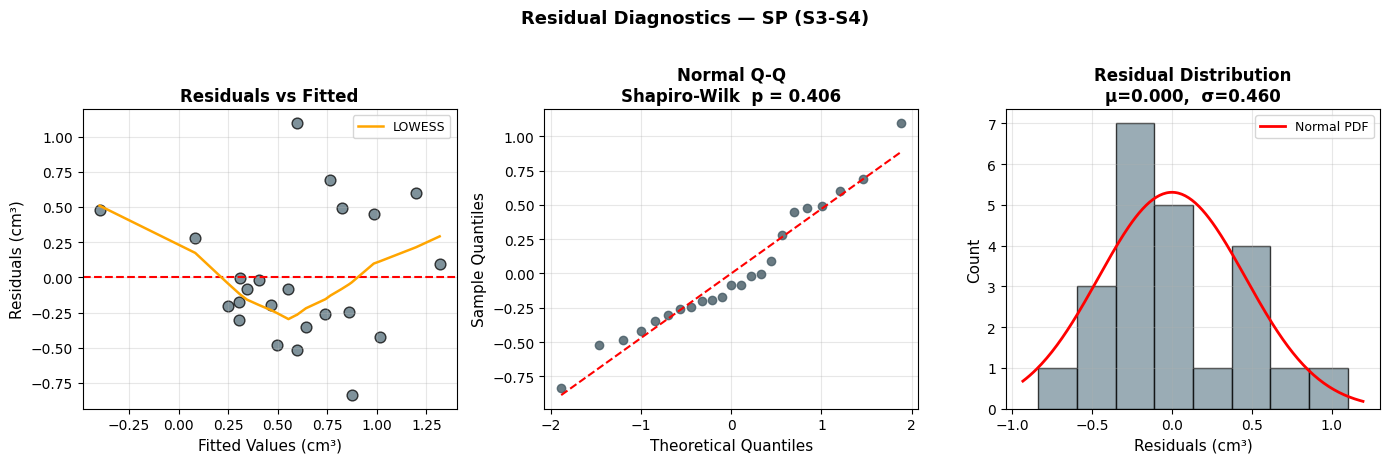

Saved: ../../assets/mv_03_qamean_cp_S1S2_partial.png
  Shapiro-Wilk [CP (S1-S2)]: W=0.9633, p=0.5324 (normal)


Saved: ../../assets/mv_03_qamean_cp_S1S2_resid.png


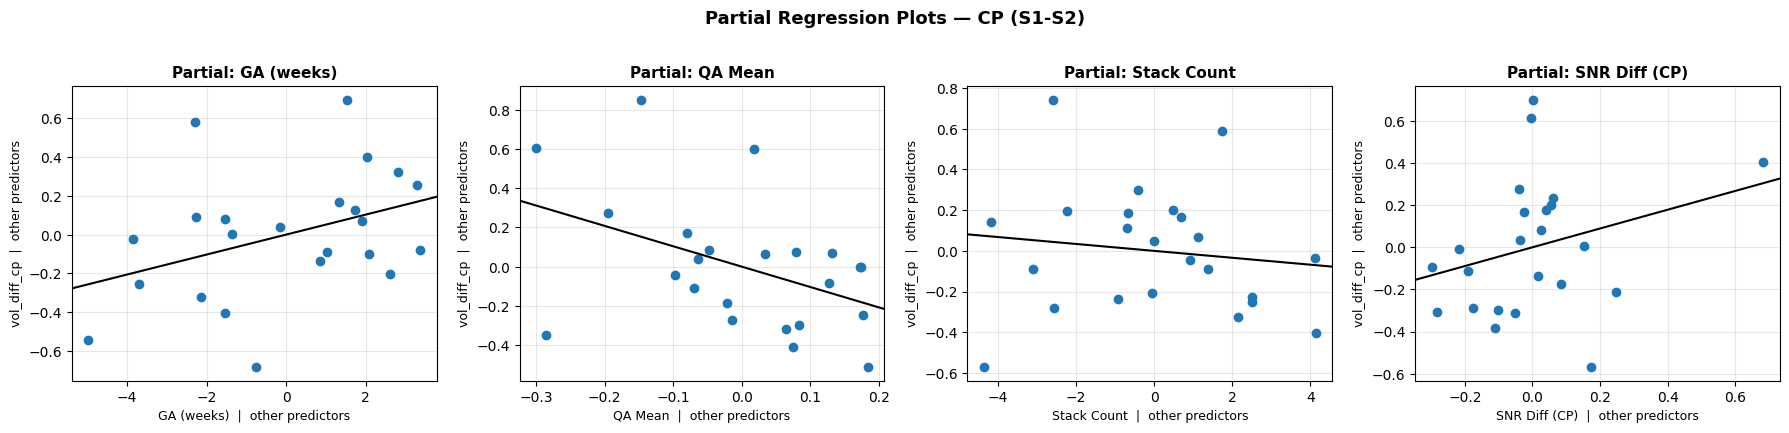

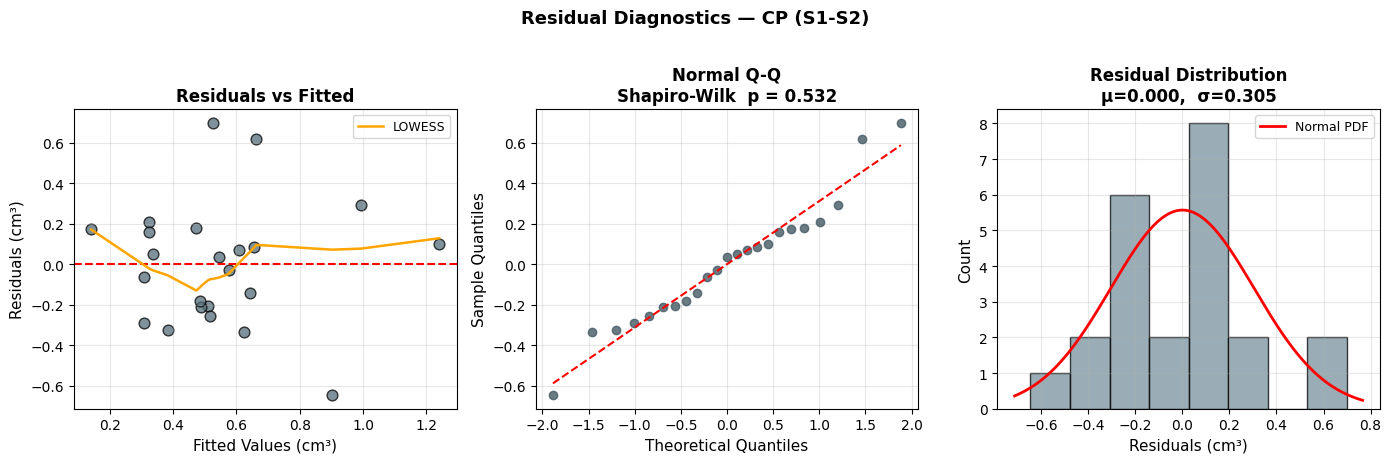

Saved: ../../assets/mv_03_qamean_cp_S3S4_partial.png
  Shapiro-Wilk [CP (S3-S4)]: W=0.8677, p=0.0058 (non-normal)


Saved: ../../assets/mv_03_qamean_cp_S3S4_resid.png


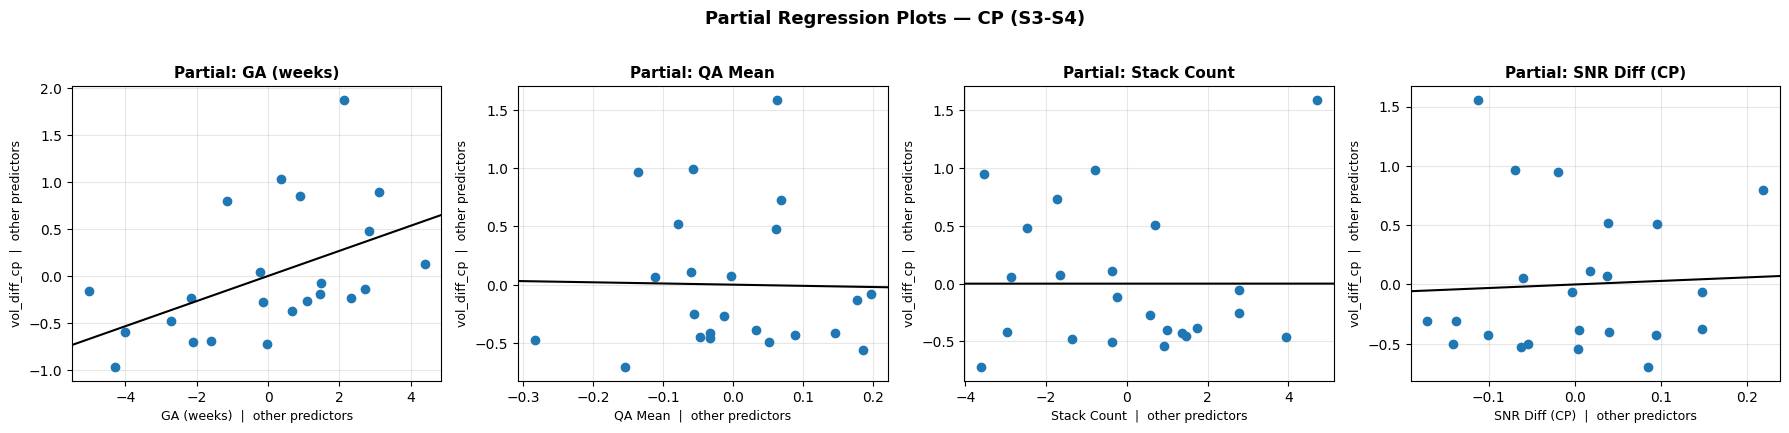

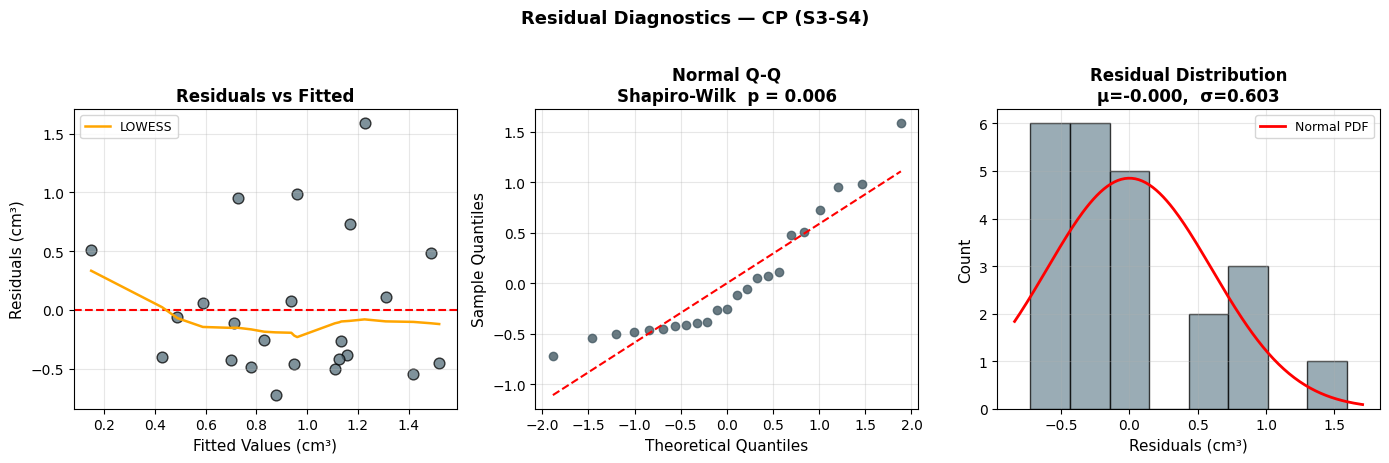

Saved: ../../assets/mv_03_qamean_table.png


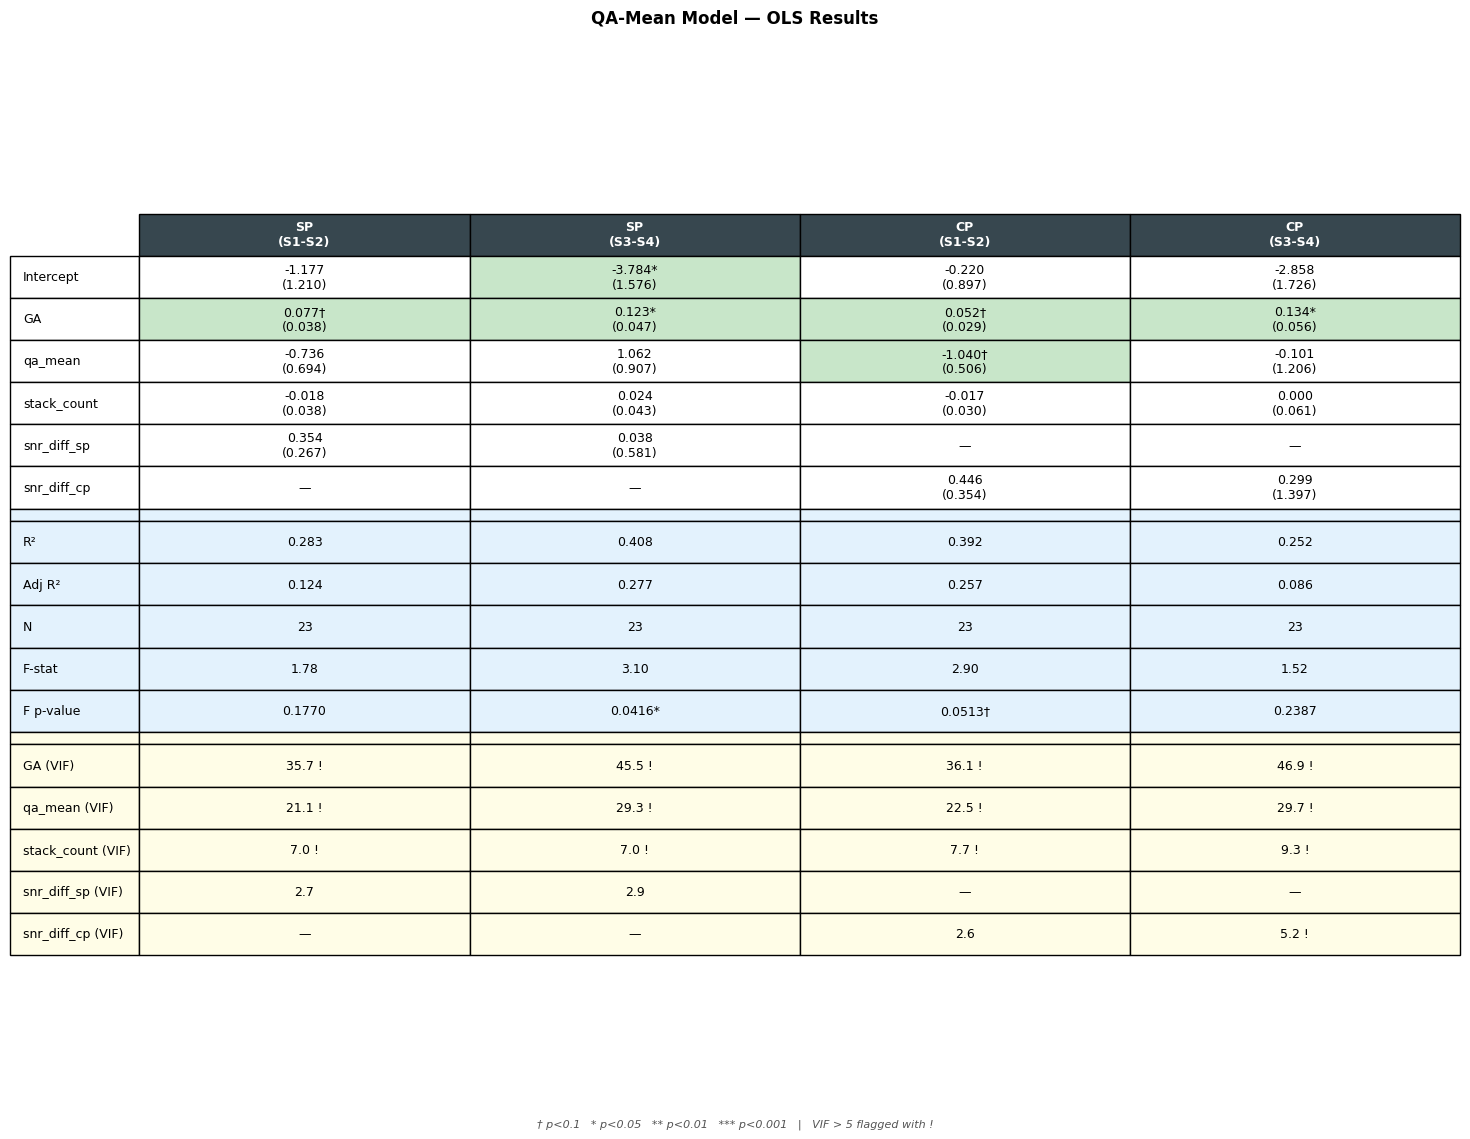

In [4]:
data_qamean_S1S2 = mf.prepare_analysis_data(quality_df, infodump_df, split_comp_df, "S1-S2")
data_qamean_S3S4 = mf.prepare_analysis_data(quality_df, infodump_df, split_comp_df, "S3-S4")

for data, split_pair in [(data_qamean_S1S2, "S1-S2"), (data_qamean_S3S4, "S3-S4")]:
    qa_mean_col = "QA12_mean" if split_pair == "S1-S2" else "QA34_mean"
    infodump_subset = infodump_df[["subject_id", "session_id", qa_mean_col]].copy()
    infodump_subset["subject_id"] = infodump_subset["subject_id"].astype(str)
    infodump_subset["session_id"] = infodump_subset["session_id"].astype(str)
    merged = data.merge(infodump_subset, on=["subject_id", "session_id"], how="left")
    merged["qa_mean"] = merged[qa_mean_col]
    if split_pair == "S1-S2": data_qamean_S1S2 = merged
    else: data_qamean_S3S4 = merged

qamean_configs = [
    (data_qamean_S1S2, "vol_diff_sp", "snr_diff_sp", "sp", "S1-S2", "Subplate"),
    (data_qamean_S3S4, "vol_diff_sp", "snr_diff_sp", "sp", "S3-S4", "Subplate"),
    (data_qamean_S1S2, "vol_diff_cp", "snr_diff_cp", "cp", "S1-S2", "Cortical Plate"),
    (data_qamean_S3S4, "vol_diff_cp", "snr_diff_cp", "cp", "S3-S4", "Cortical Plate"),
]

results_qamean = []
for data, outcome_col, snr_col, tissue, split_pair, tissue_name in qamean_configs:
    result = run_regression_model(df=data, outcome_col=outcome_col,
        predictors=["GA", "qa_mean", "stack_count", snr_col],
        model_name="QA-Mean", split_pair=split_pair, tissue=tissue)
    results_qamean.append(result)

compare_models(results_qamean)

fig = plot_coefficients(results_qamean, title="QA-Mean: Vol_diff ~ GA + SNR_diff + QA_mean + stack_count",
    predictor_labels=PRED_LABELS, save_path=f"{ASSETS}/mv_03_qamean_coef.png")
plt.show()

for i, (data, outcome_col, snr_col, tissue, split_pair, tissue_name) in enumerate(qamean_configs):
    r = results_qamean[i]
    if r is None: continue
    slug = f"{tissue}_{split_pair.replace('-','')}"
    fig1, fig2 = plot_diagnostic_suite(data, outcome_col, r,
        tissue_name=tissue.upper(), split_pair=split_pair,
        predictor_labels=PRED_LABELS,
        save_path_prefix=f"{ASSETS}/mv_03_qamean_{slug}")
    plt.show(); plt.show()

fig = plot_ols_table(results_qamean, title="QA-Mean Model — OLS Results",
    save_path=f"{ASSETS}/mv_03_qamean_table.png")
plt.show()


## Vol_diff ~ GA + CNR_diff/CNR_mean + QA_diff + stack_count


Table: Regression of SP Volume Diff (S1-S2)
Variable        Coef      SE       t    p-value
-----------  -------  ------  ------  ---------
Intercept     -1.776   1.199  -1.480      0.156
GA             0.075   0.040   1.880      0.077
cnr_diff     104.927  99.454   1.060      0.305
qa_diff       -0.762   1.370  -0.560      0.585
stack_count    0.017   0.036   0.470      0.643
R-squared            0.222
Adj. R-squared       0.049
N                       23
F-statistic           1.28

Collinearity Statistics (VIF):
  Variable             VIF
  -------------------------
  GA                 12.51 *
  cnr_diff            3.46
  qa_diff             2.68
  stack_count         5.98 *

Table: Regression of SP Volume Diff (S3-S4)
Variable        Coef      SE       t  p-value
-----------  -------  ------  ------  ---------
Intercept     -2.776   1.204  -2.310  0.033 *
GA             0.107   0.042   2.560  0.020 *
cnr_diff     -18.410  72.959  -0.250  0.804
qa_diff        2.913   1.516   1.920 

Saved: ../../assets/mv_04_cnrdiff_coef.png


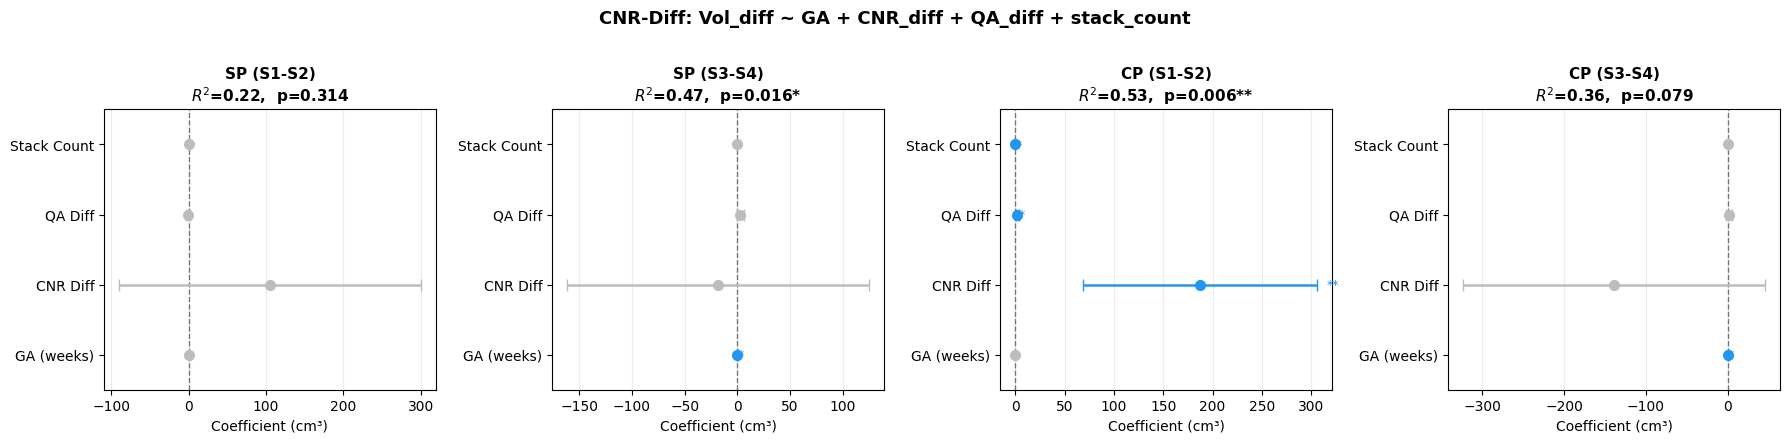

Saved: ../../assets/mv_04_cnrdiff_sp_S1S2_partial.png
  Shapiro-Wilk [SP (S1-S2)]: W=0.9776, p=0.8612 (normal)


Saved: ../../assets/mv_04_cnrdiff_sp_S1S2_resid.png


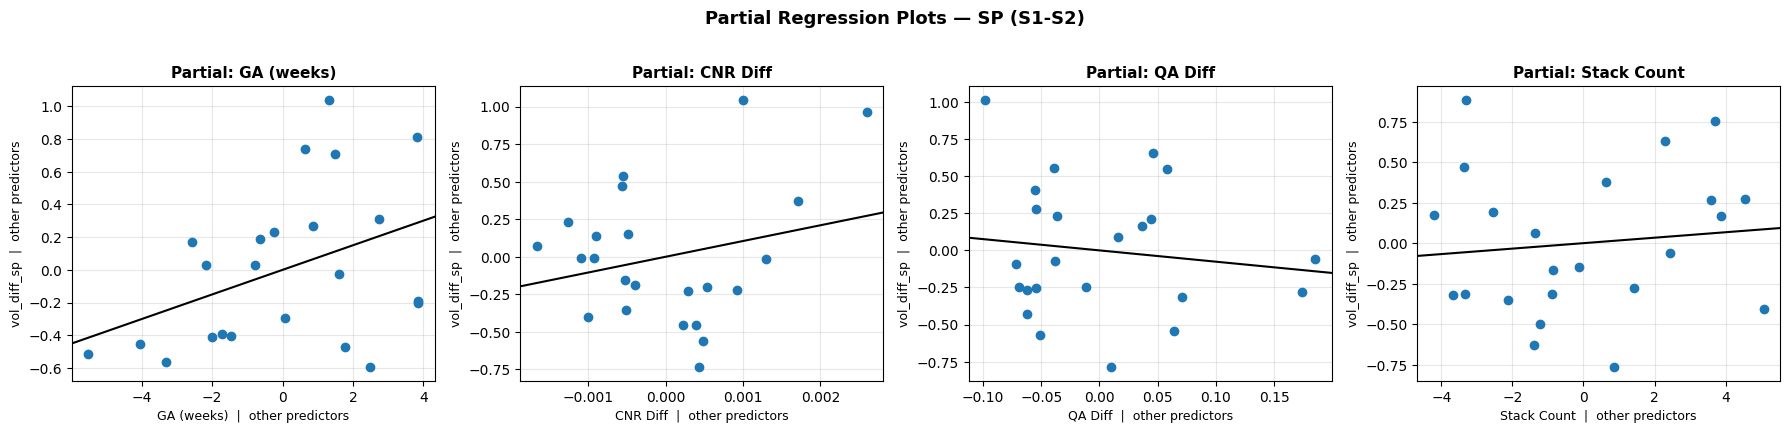

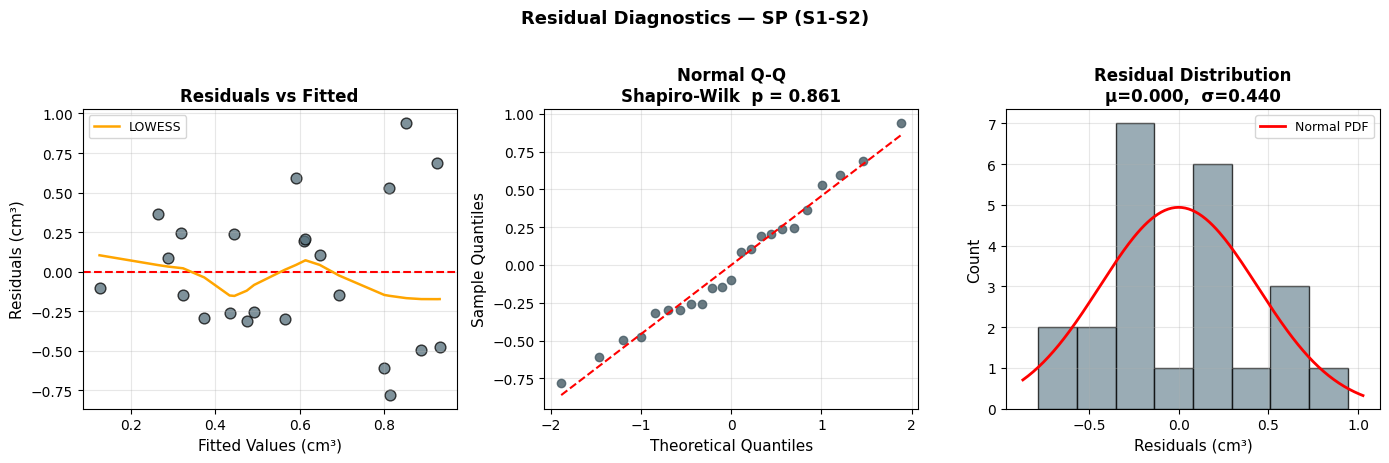

Saved: ../../assets/mv_04_cnrdiff_sp_S3S4_partial.png
  Shapiro-Wilk [SP (S3-S4)]: W=0.9683, p=0.6490 (normal)


Saved: ../../assets/mv_04_cnrdiff_sp_S3S4_resid.png


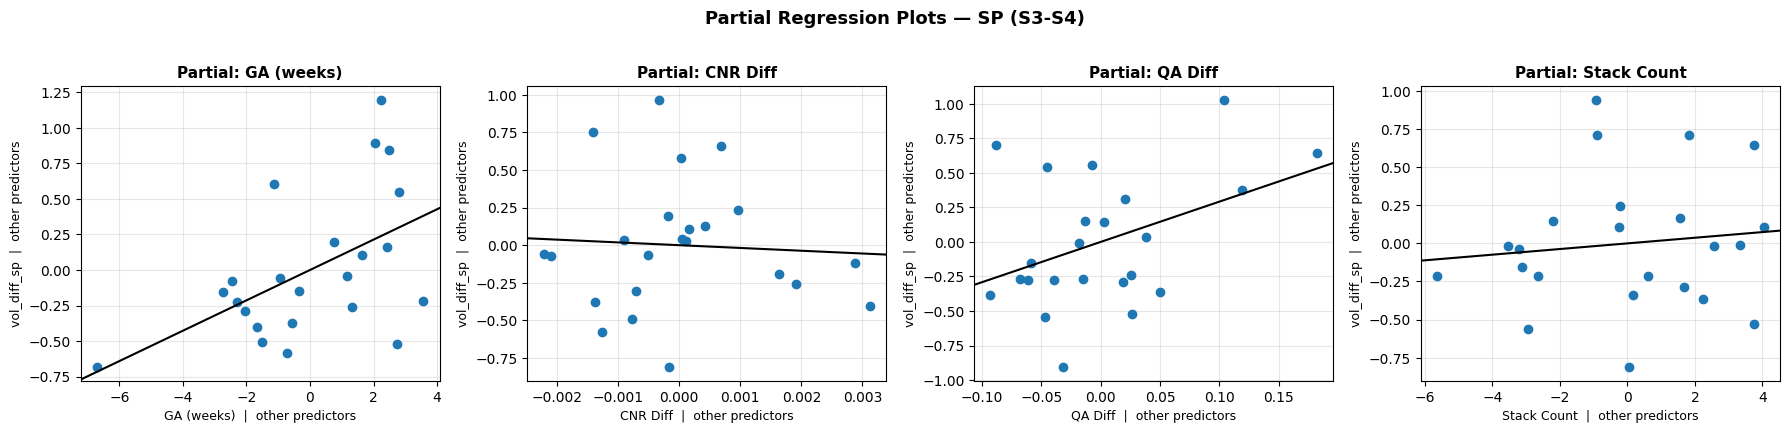

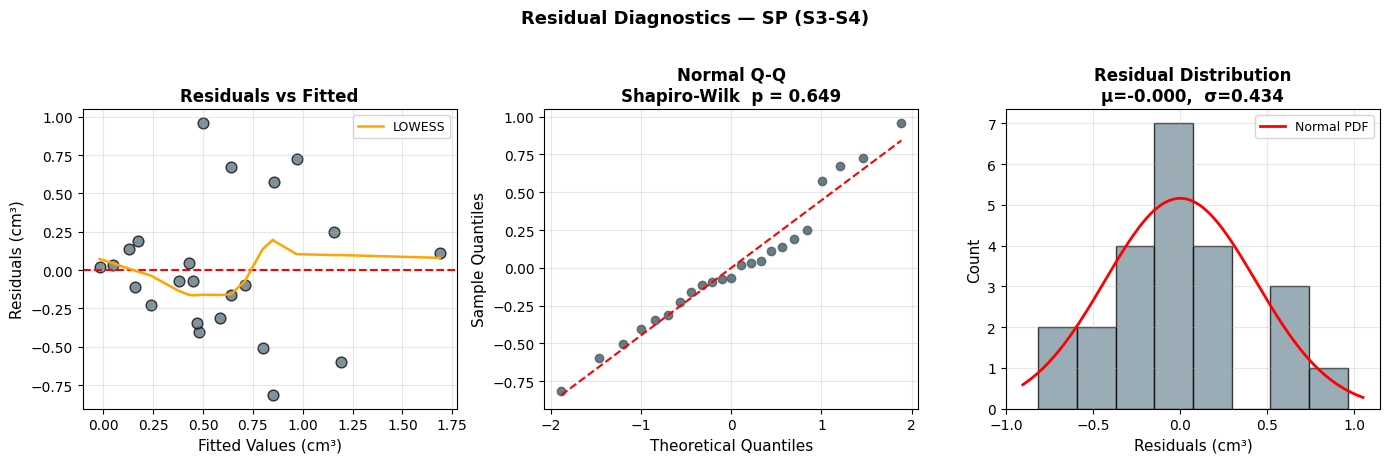

Saved: ../../assets/mv_04_cnrdiff_cp_S1S2_partial.png
  Shapiro-Wilk [CP (S1-S2)]: W=0.9905, p=0.9976 (normal)


Saved: ../../assets/mv_04_cnrdiff_cp_S1S2_resid.png


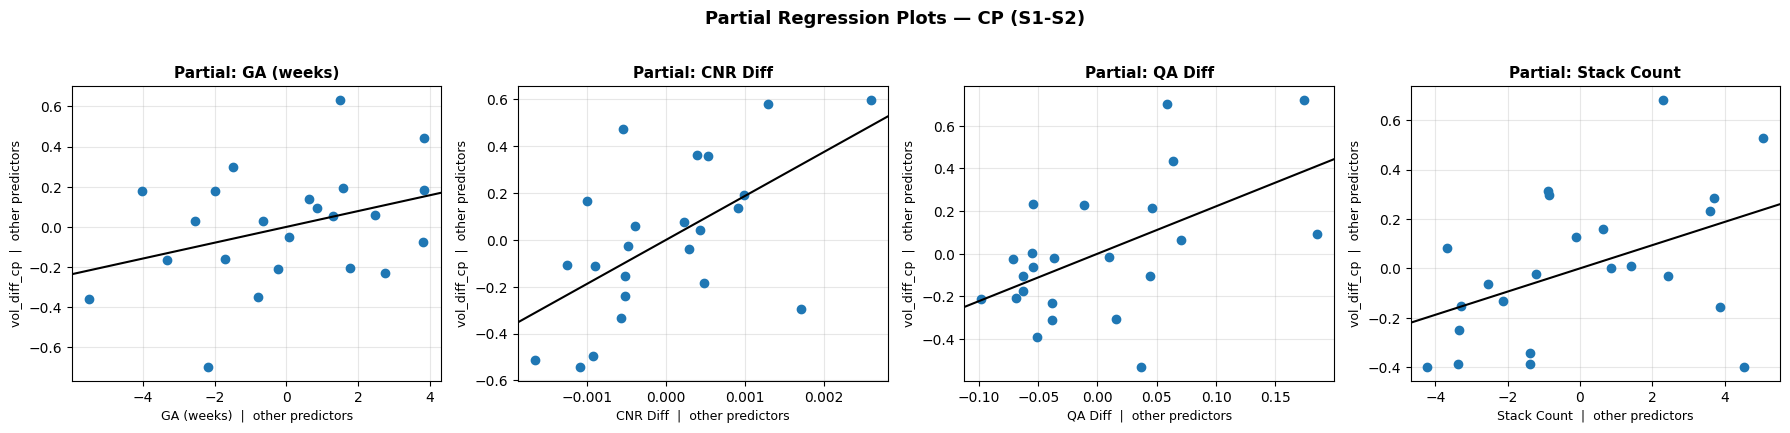

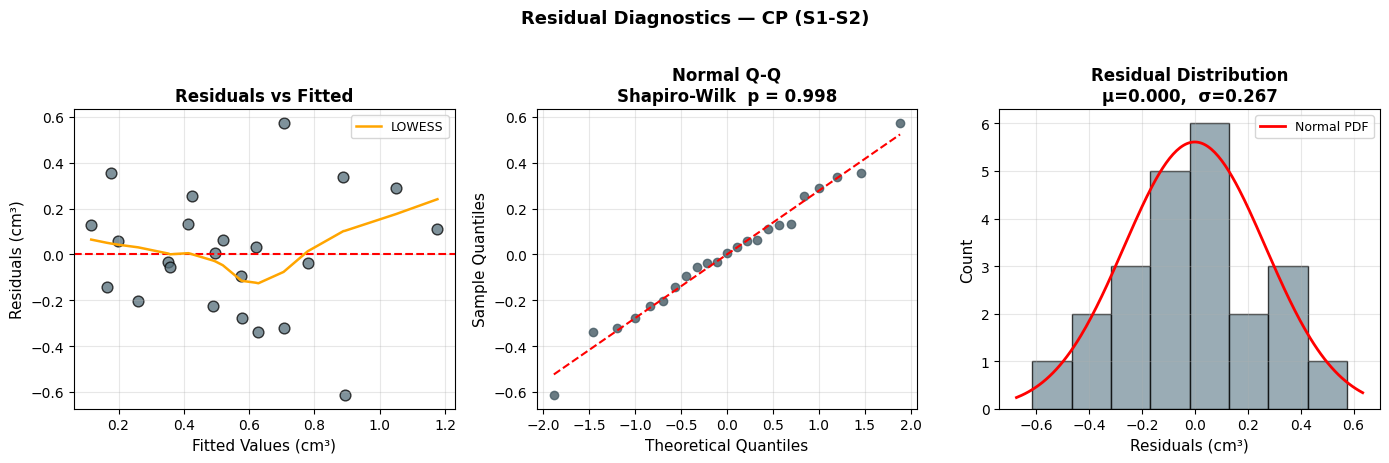

Saved: ../../assets/mv_04_cnrdiff_cp_S3S4_partial.png
  Shapiro-Wilk [CP (S3-S4)]: W=0.8949, p=0.0199 (non-normal)


Saved: ../../assets/mv_04_cnrdiff_cp_S3S4_resid.png


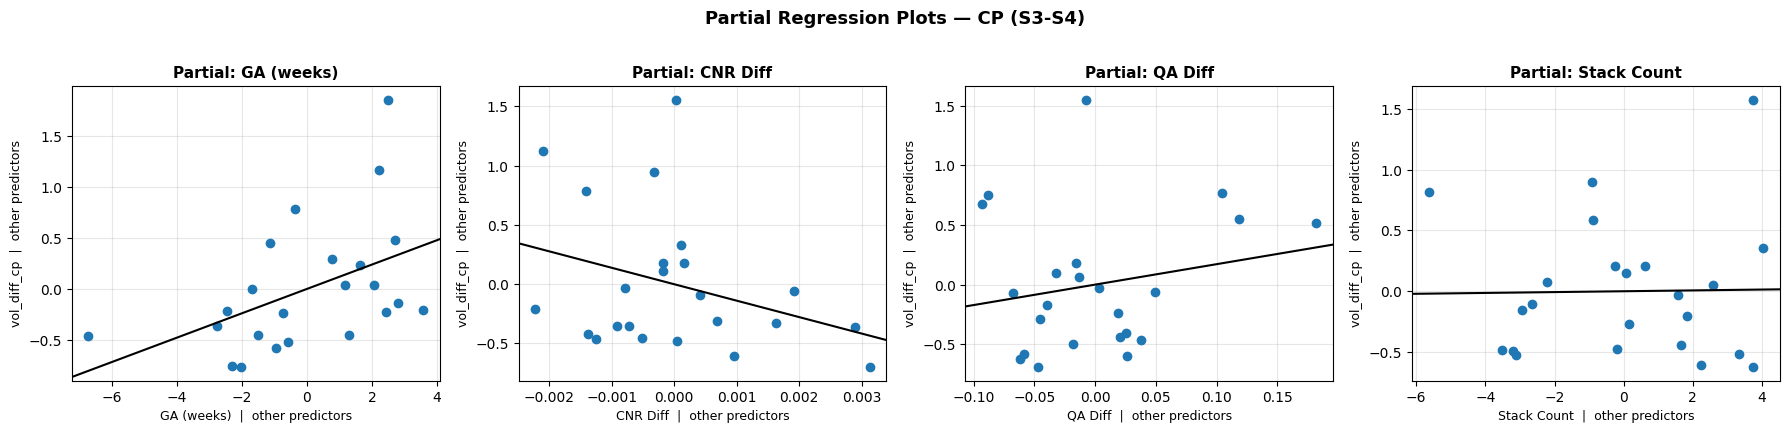

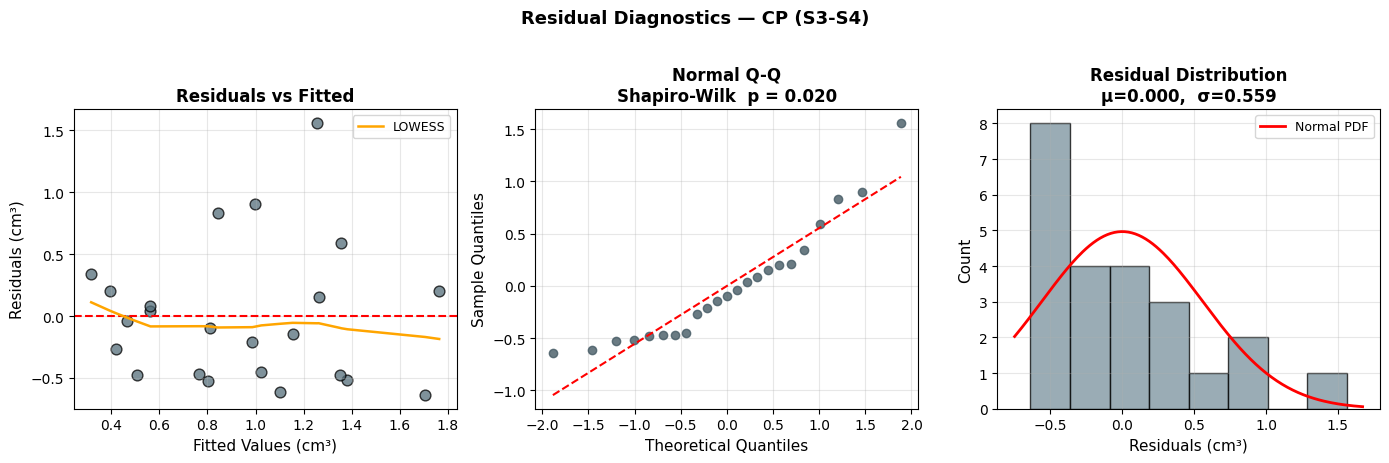

Saved: ../../assets/mv_04_cnrdiff_table.png


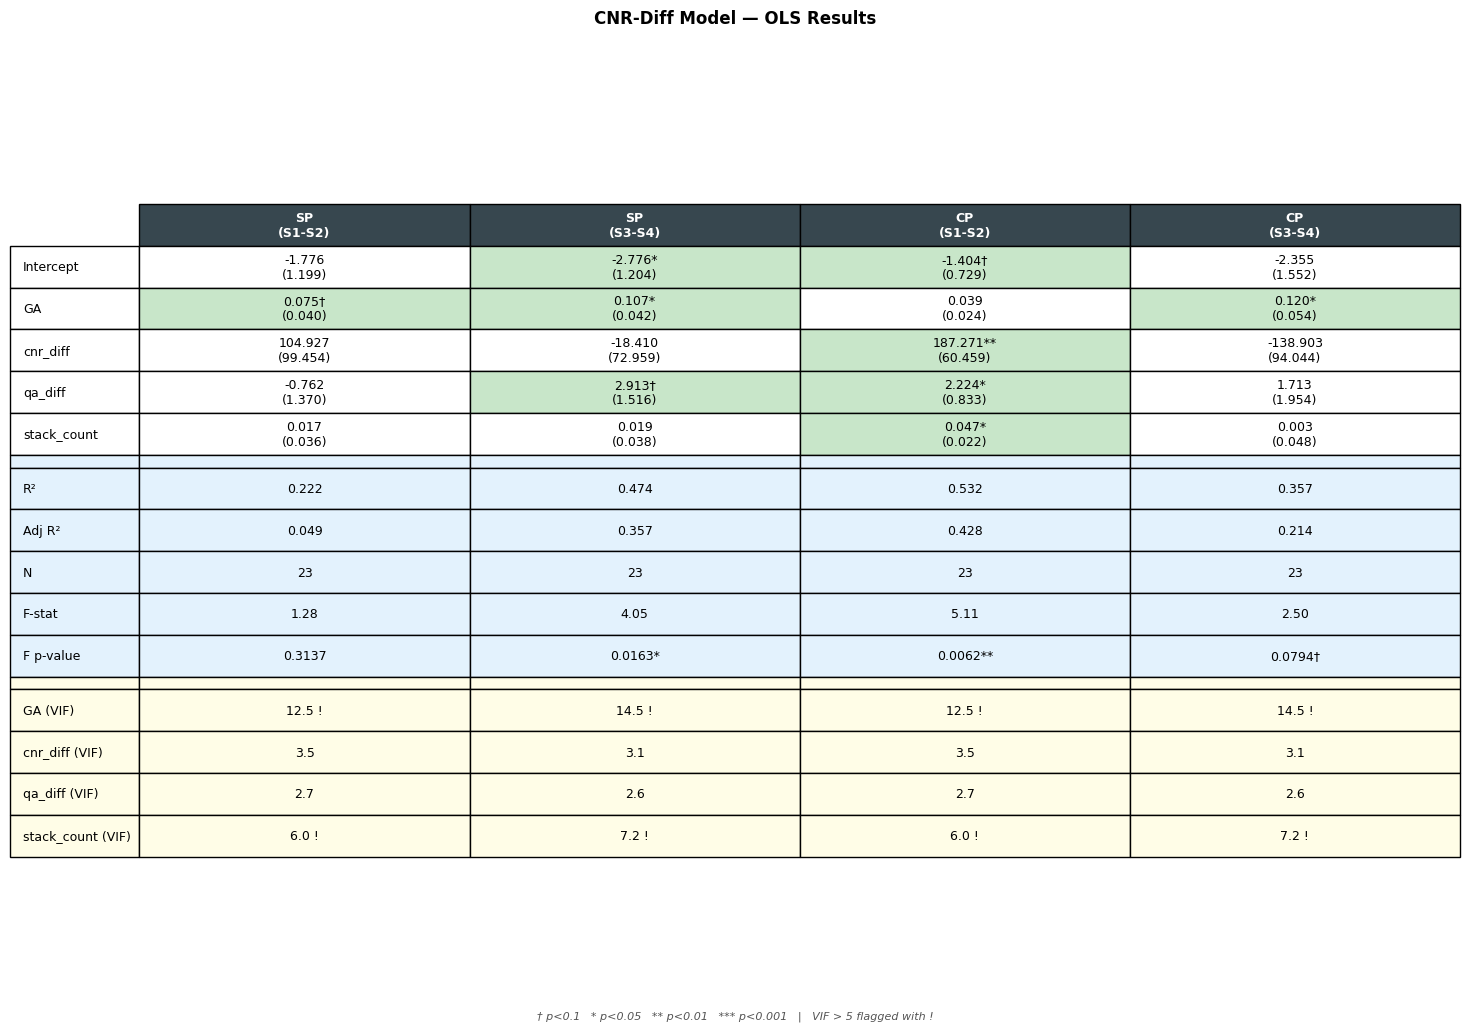

In [5]:
data_cnr_S1S2 = mf.prepare_analysis_data(quality_df, infodump_df, split_comp_df, "S1-S2")
data_cnr_S3S4 = mf.prepare_analysis_data(quality_df, infodump_df, split_comp_df, "S3-S4")

cnr_diff_predictors = ["GA", "cnr_diff", "qa_diff", "stack_count"]
cnr_mean_predictors = ["GA", "cnr_mean", "qa_diff", "stack_count"]

cnr_configs = [
    (data_cnr_S1S2, "vol_diff_sp", "sp", "S1-S2", "Subplate"),
    (data_cnr_S3S4, "vol_diff_sp", "sp", "S3-S4", "Subplate"),
    (data_cnr_S1S2, "vol_diff_cp", "cp", "S1-S2", "Cortical Plate"),
    (data_cnr_S3S4, "vol_diff_cp", "cp", "S3-S4", "Cortical Plate"),
]

results_cnr_diff = []
for data, outcome_col, tissue, split_pair, tissue_name in cnr_configs:
    result = run_regression_model(df=data, outcome_col=outcome_col,
        predictors=cnr_diff_predictors,
        model_name="CNR-Diff", split_pair=split_pair, tissue=tissue)
    results_cnr_diff.append(result)

compare_models(results_cnr_diff)

fig = plot_coefficients(results_cnr_diff, title="CNR-Diff: Vol_diff ~ GA + CNR_diff + QA_diff + stack_count",
    predictor_labels=PRED_LABELS, save_path=f"{ASSETS}/mv_04_cnrdiff_coef.png")
plt.show()

for i, (data, outcome_col, tissue, split_pair, tissue_name) in enumerate(cnr_configs):
    r = results_cnr_diff[i]
    if r is None: continue
    slug = f"{tissue}_{split_pair.replace('-','')}"
    fig1, fig2 = plot_diagnostic_suite(data, outcome_col, r,
        tissue_name=tissue.upper(), split_pair=split_pair,
        predictor_labels=PRED_LABELS,
        save_path_prefix=f"{ASSETS}/mv_04_cnrdiff_{slug}")
    plt.show(); plt.show()

fig = plot_ols_table(results_cnr_diff, title="CNR-Diff Model — OLS Results",
    save_path=f"{ASSETS}/mv_04_cnrdiff_table.png")
plt.show()



Table: Regression of SP Volume Diff (S1-S2)
Variable       Coef      SE       t    p-value
-----------  ------  ------  ------  ---------
Intercept    -1.804   1.458  -1.240      0.232
GA            0.082   0.045   1.820      0.085
cnr_mean      6.338  27.520   0.230      0.820
qa_diff      -0.956   1.397  -0.680      0.503
stack_count   0.010   0.036   0.270      0.793
R-squared            0.176
Adj. R-squared      -0.007
N                       23
F-statistic           0.96

Collinearity Statistics (VIF):
  Variable             VIF
  -------------------------
  GA                 10.57 *
  cnr_mean            4.74
  qa_diff             2.63
  stack_count         6.04 *

Table: Regression of SP Volume Diff (S3-S4)
Variable       Coef      SE       t  p-value
-----------  ------  ------  ------  ---------
Intercept    -2.686   1.459  -1.840  0.082
GA            0.103   0.048   2.150  0.045 *
cnr_mean     -3.942  26.474  -0.150  0.883
qa_diff       2.961   1.543   1.920  0.071
stack_co

Saved: ../../assets/mv_05_cnrmean_coef.png


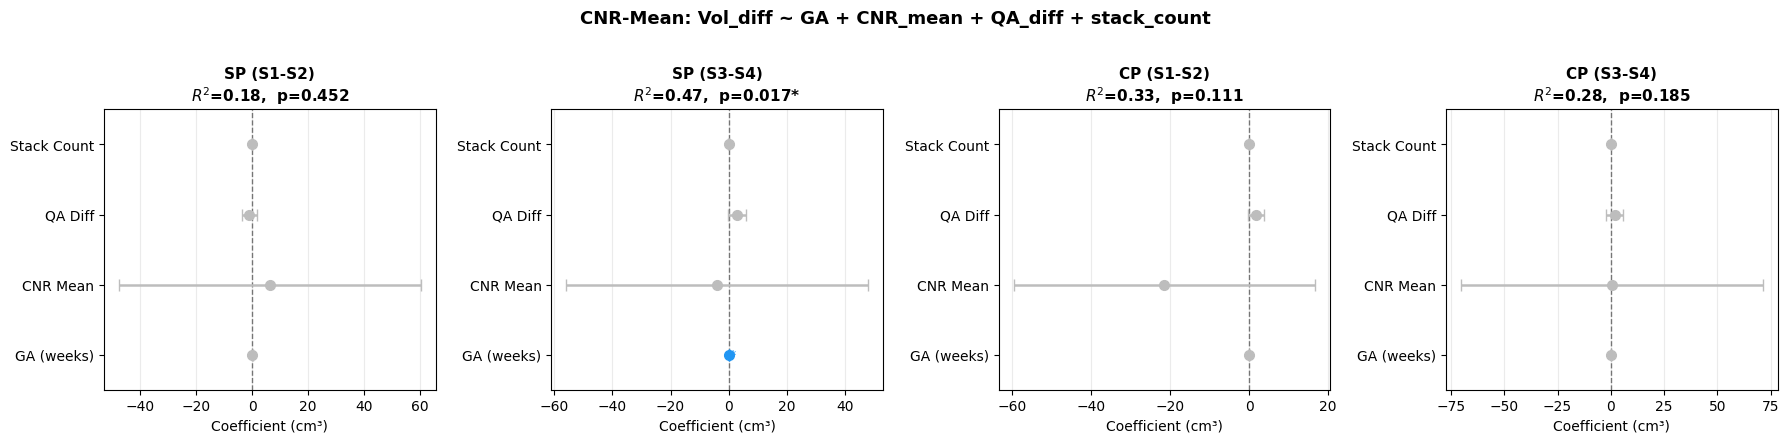

Saved: ../../assets/mv_05_cnrmean_sp_S1S2_partial.png
  Shapiro-Wilk [SP (S1-S2)]: W=0.9427, p=0.2054 (normal)


Saved: ../../assets/mv_05_cnrmean_sp_S1S2_resid.png


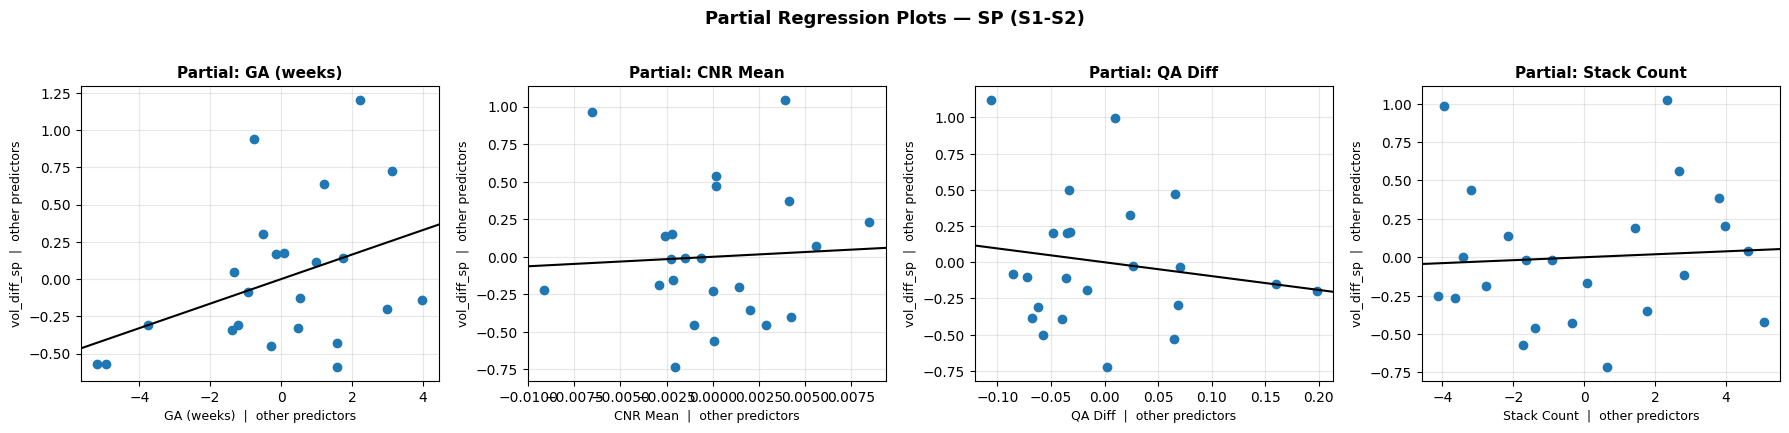

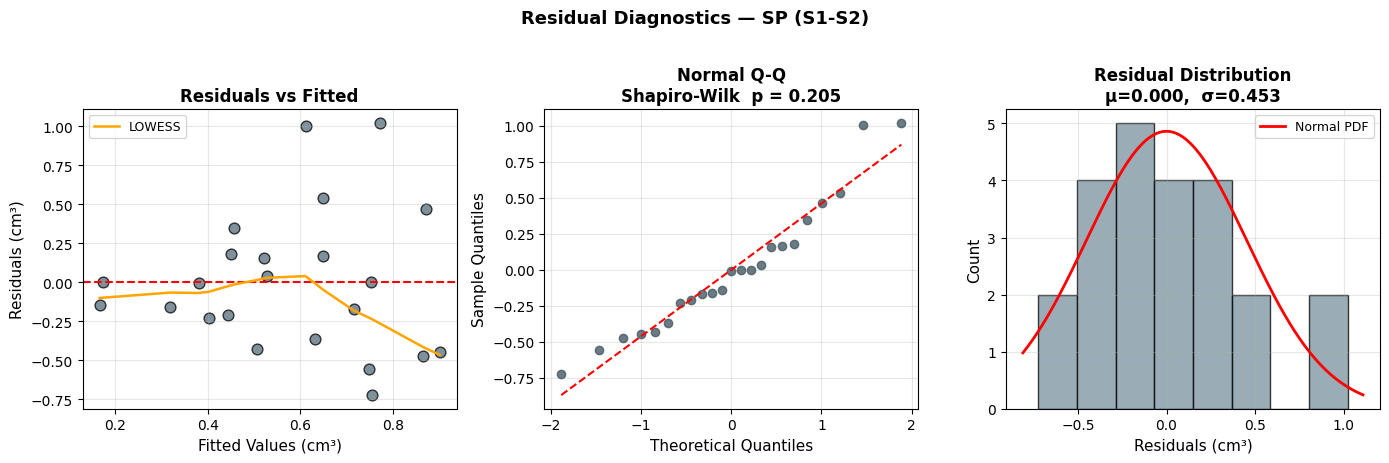

Saved: ../../assets/mv_05_cnrmean_sp_S3S4_partial.png
  Shapiro-Wilk [SP (S3-S4)]: W=0.9676, p=0.6312 (normal)


Saved: ../../assets/mv_05_cnrmean_sp_S3S4_resid.png


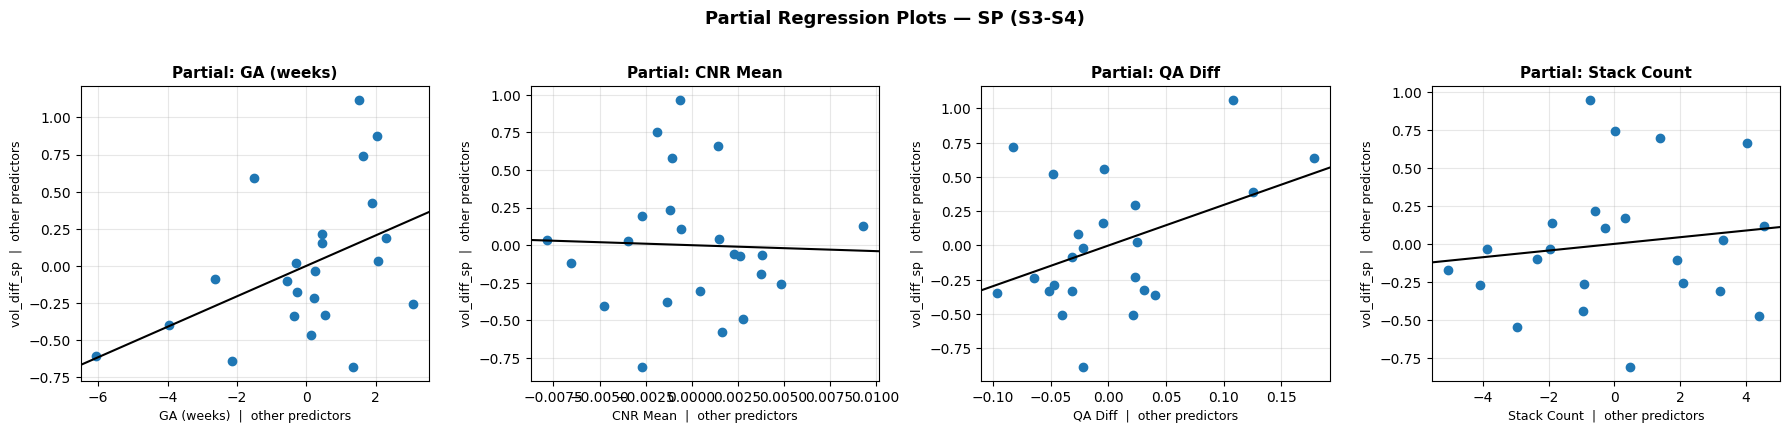

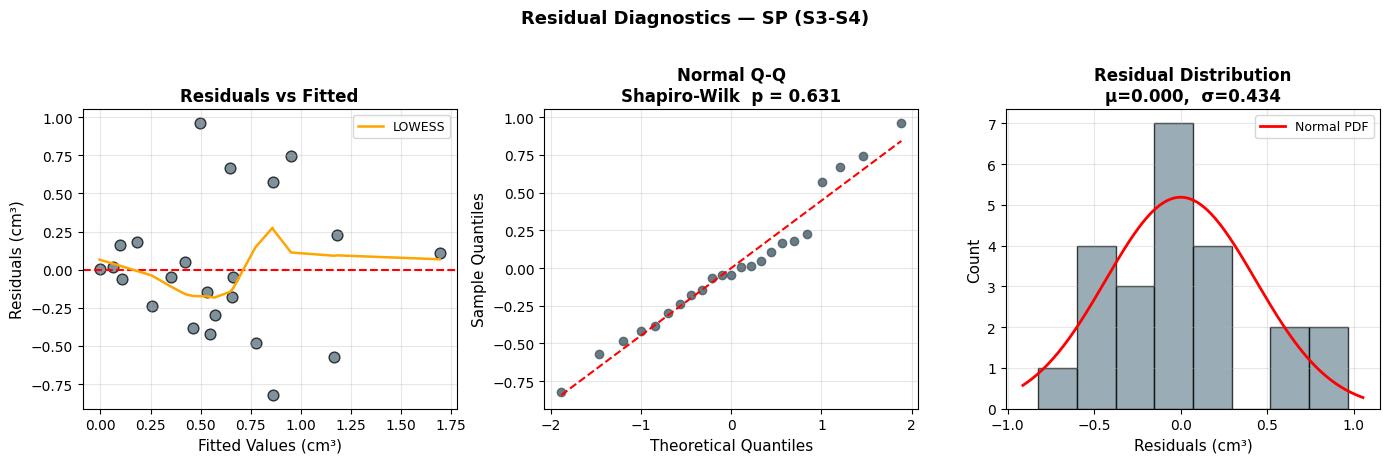

Saved: ../../assets/mv_05_cnrmean_cp_S1S2_partial.png
  Shapiro-Wilk [CP (S1-S2)]: W=0.9597, p=0.4574 (normal)


Saved: ../../assets/mv_05_cnrmean_cp_S1S2_resid.png


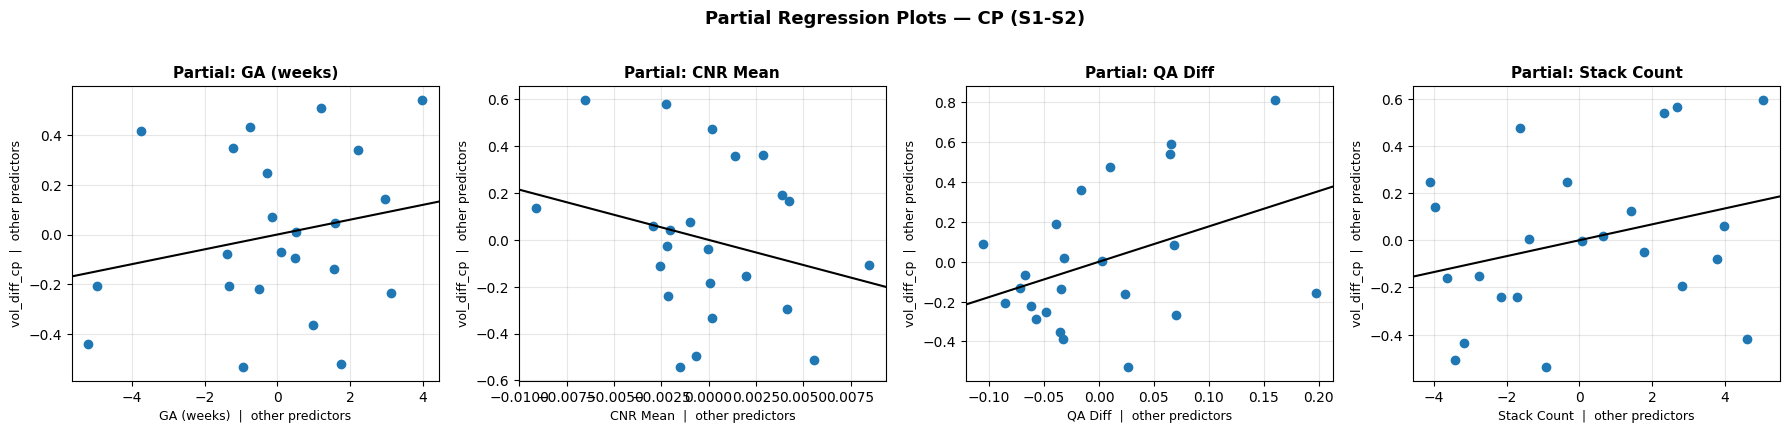

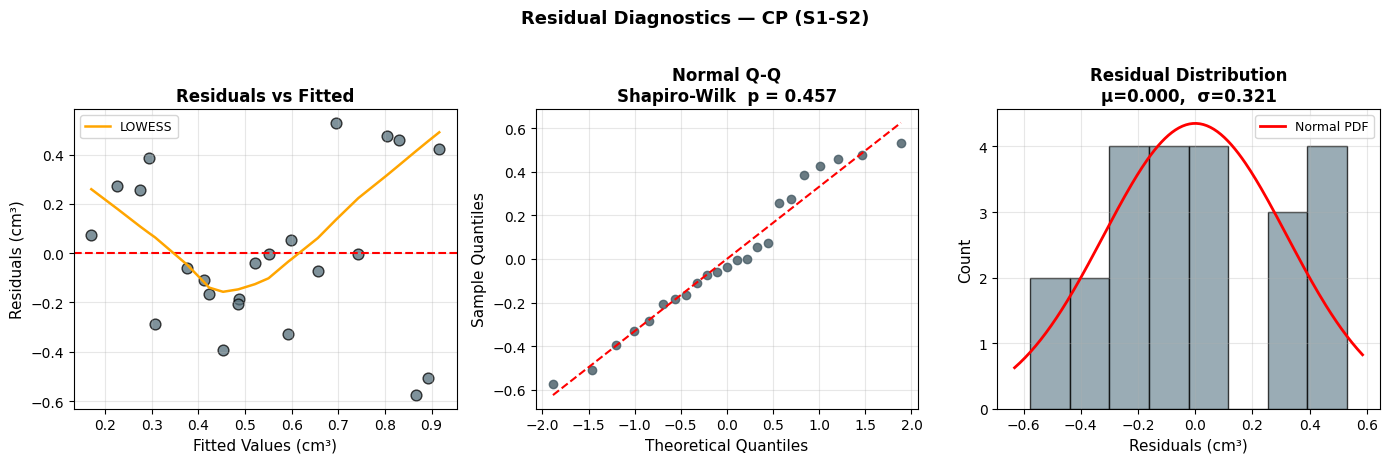

Saved: ../../assets/mv_05_cnrmean_cp_S3S4_partial.png
  Shapiro-Wilk [CP (S3-S4)]: W=0.8600, p=0.0041 (non-normal)


Saved: ../../assets/mv_05_cnrmean_cp_S3S4_resid.png


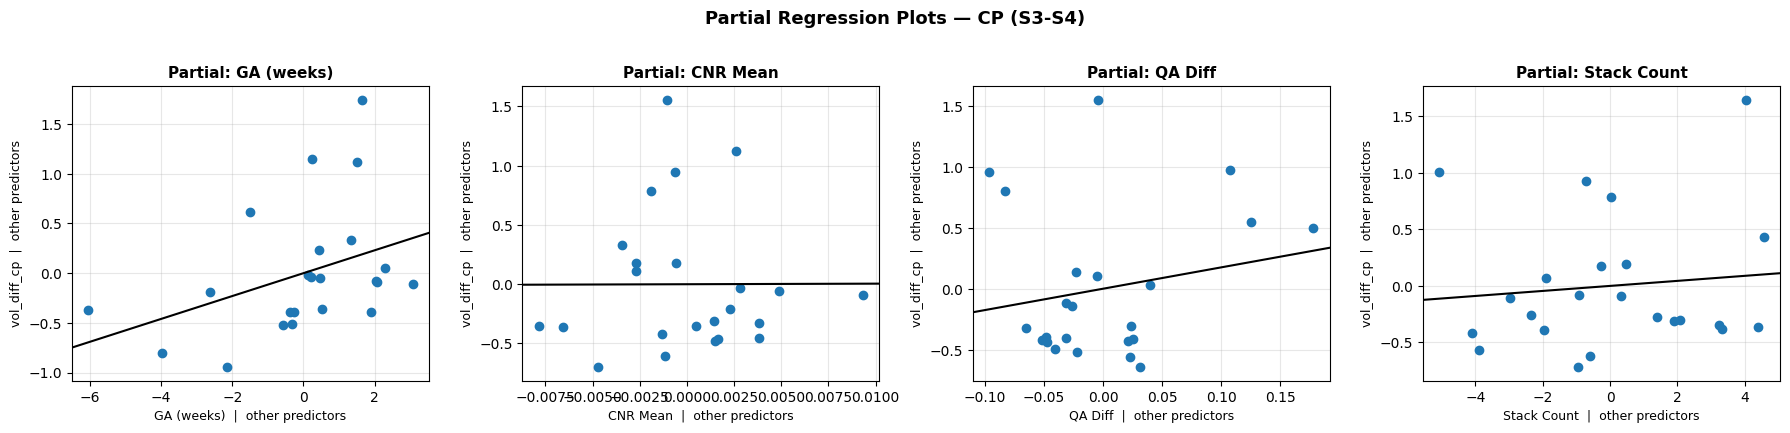

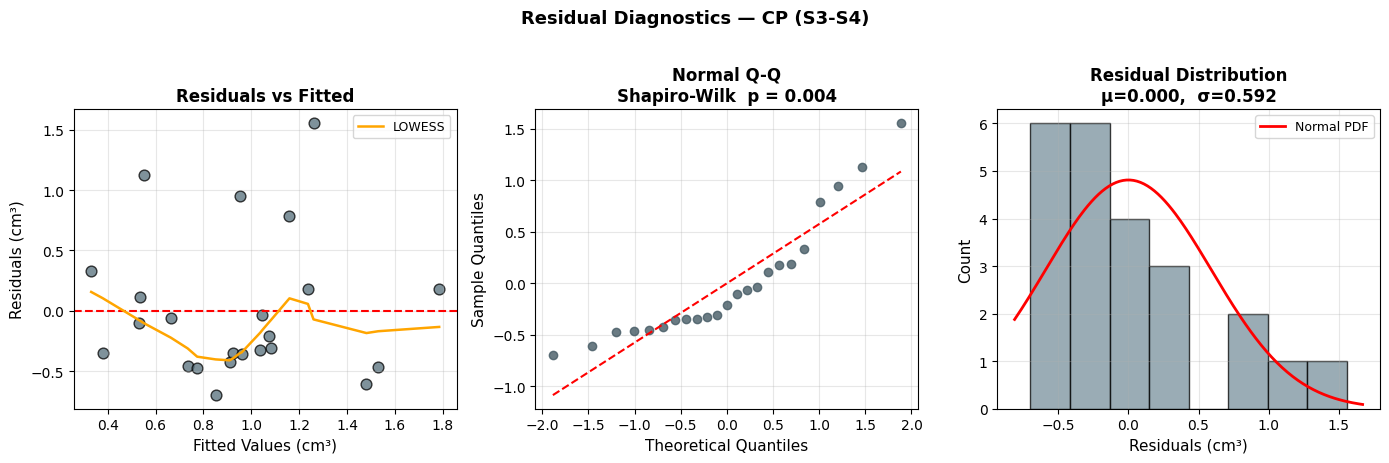

Saved: ../../assets/mv_05_cnrmean_table.png


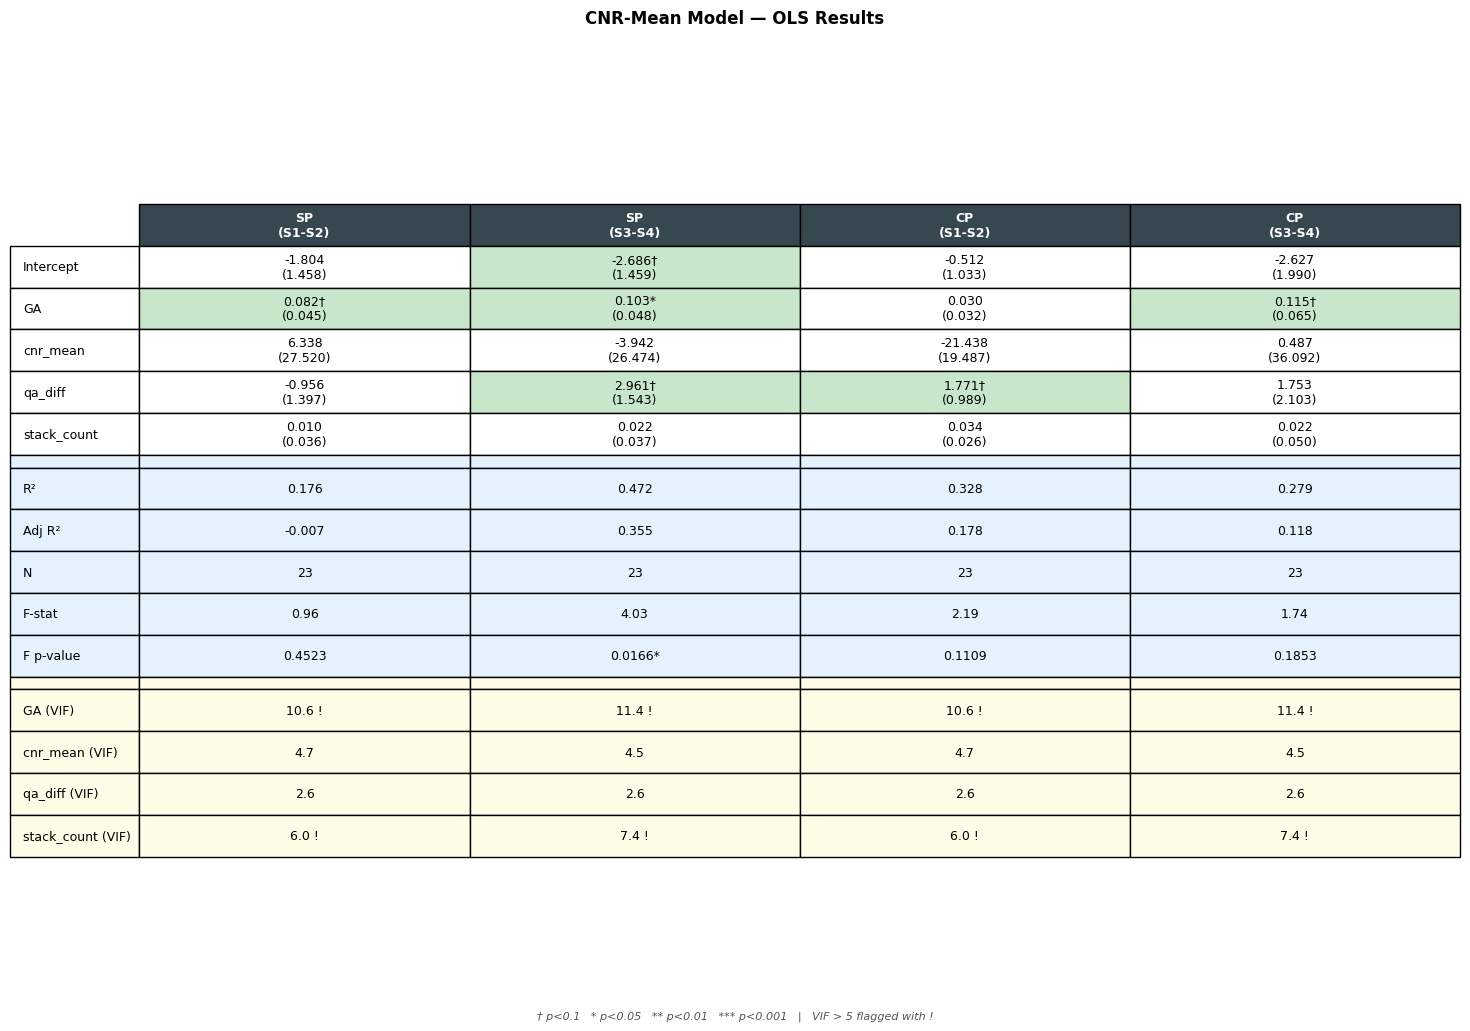

In [6]:
results_cnr_mean = []
for data, outcome_col, tissue, split_pair, tissue_name in cnr_configs:
    result = run_regression_model(df=data, outcome_col=outcome_col,
        predictors=cnr_mean_predictors,
        model_name="CNR-Mean", split_pair=split_pair, tissue=tissue)
    results_cnr_mean.append(result)

compare_models(results_cnr_mean)

fig = plot_coefficients(results_cnr_mean, title="CNR-Mean: Vol_diff ~ GA + CNR_mean + QA_diff + stack_count",
    predictor_labels=PRED_LABELS, save_path=f"{ASSETS}/mv_05_cnrmean_coef.png")
plt.show()

for i, (data, outcome_col, tissue, split_pair, tissue_name) in enumerate(cnr_configs):
    r = results_cnr_mean[i]
    if r is None: continue
    slug = f"{tissue}_{split_pair.replace('-','')}"
    fig1, fig2 = plot_diagnostic_suite(data, outcome_col, r,
        tissue_name=tissue.upper(), split_pair=split_pair,
        predictor_labels=PRED_LABELS,
        save_path_prefix=f"{ASSETS}/mv_05_cnrmean_{slug}")
    plt.show(); plt.show()

fig = plot_ols_table(results_cnr_mean, title="CNR-Mean Model — OLS Results",
    save_path=f"{ASSETS}/mv_05_cnrmean_table.png")
plt.show()


## Model Comparison

Saved: ../../assets/mv_06_r2_comparison.png


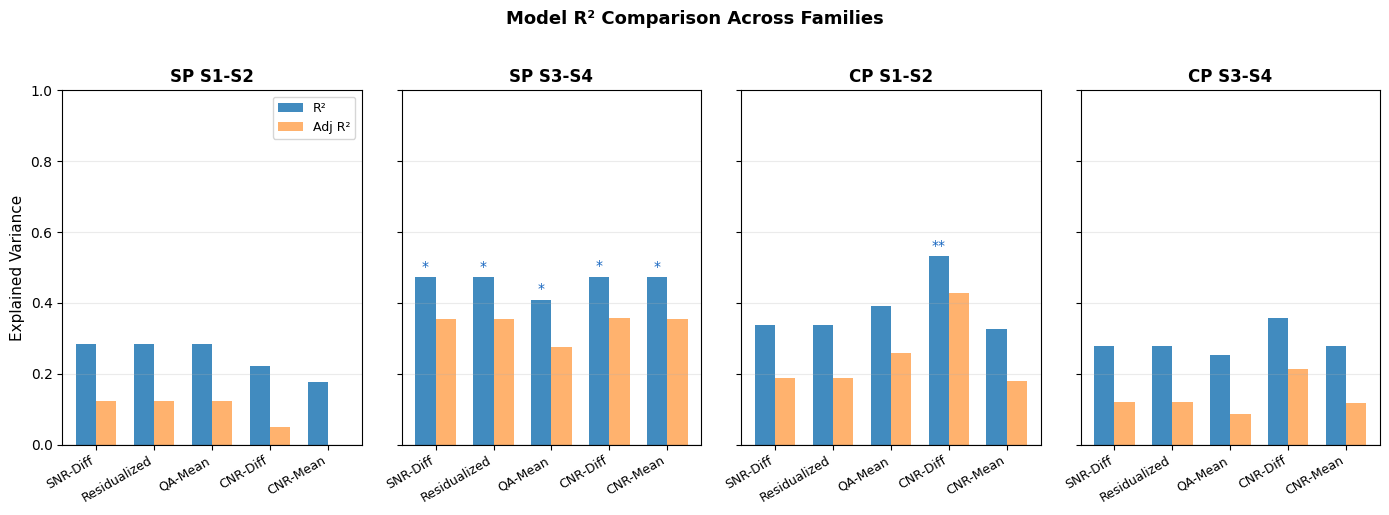

In [7]:
all_results = {
    "SNR-Diff":     results_snr,
    "Residualized": results_resid,
    "QA-Mean":      results_qamean,
    "CNR-Diff":     results_cnr_diff,
    "CNR-Mean":     results_cnr_mean,
}
fig = plot_r2_comparison(all_results, save_path=f"{ASSETS}/mv_06_r2_comparison.png")
plt.show()
